In [ ]:
!pip install pyquery

You should consider upgrading via the '/Users/hinjam/Documents/PJ/venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
!pip install nltk

You should consider upgrading via the '/Users/hinjam/Documents/PJ/venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
!python3 -m pip show pyquery

Name: pyquery
Version: 2.0.1
Summary: A jquery-like library for python
Home-page: https://github.com/gawel/pyquery
Author: Olivier Lauzanne
Author-email: olauzanne@gmail.com
License: BSD
Location: /Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages
Requires: lxml, cssselect
Required-by: 


In [ ]:
!pip install tld

You should consider upgrading via the '/Users/hinjam/Documents/PJ/venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
!python3 -m pip show tld

Name: tld
Version: 0.13
Summary: Extract the top-level domain (TLD) from the URL given.
Home-page: https://github.com/barseghyanartur/tld
Author: Artur Barseghyan
Author-email: artur.barseghyan@gmail.com
License: MPL-1.1 OR GPL-2.0-only OR LGPL-2.1-or-later
Location: /Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages
Requires: 
Required-by: 


In [ ]:
!pip install colorama

You should consider upgrading via the '/Users/hinjam/Documents/PJ/venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
!python3 -m pip show scikit-learn

Name: scikit-learn
Version: 1.2.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: /Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages
Requires: scipy, threadpoolctl, numpy, joblib
Required-by: scikit-plot


In [ ]:
! pip install -q scikit-plot

You should consider upgrading via the '/Users/hinjam/Documents/PJ/venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import log
from colorama import Fore
from urllib.parse import urlparse
from tld import get_tld, is_tld
from re import compile
from urllib.parse import urlparse
from socket import gethostbyname
from pyquery import PyQuery

import scikitplot as skplt
from requests import get
from json import dump
from string import ascii_lowercase
from numpy import array
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# import tensorflow as tf
# from tensorflow.python.util import deprecation
# from tensorflow.keras.utils import to_categorical
import gc
import random
import os
import pickle
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from tensorflow.keras import models, layers, backend, metrics
# from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, auc, classification_report
from sklearn.preprocessing import label_binarize


In [ ]:
df=pd.read_csv('malicious_phish.csv')

In [ ]:
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [ ]:
df.isnull().sum()

url     0
type    0
dtype: int64

In [ ]:
count = df.type.value_counts()
count

benign        428103
defacement     96457
phishing       94111
malware        32520
Name: type, dtype: int64

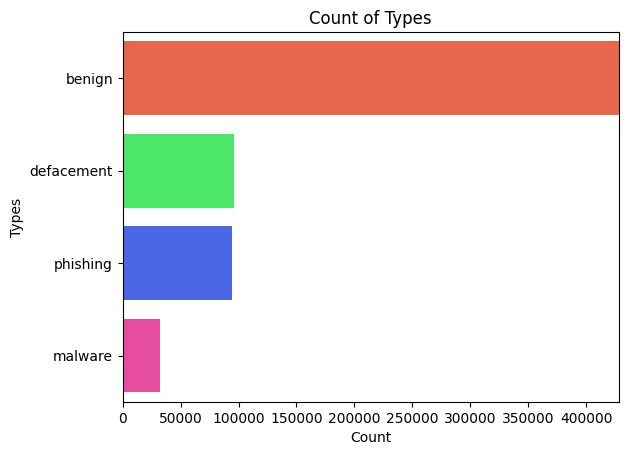

In [ ]:
import matplotlib.pyplot as plt

custom_palette = ["#FF5733", "#33FF57", "#3357FF", "#FF33A1"]
sns.barplot(y=count.index, x=count, palette=custom_palette, hue=count.index, dodge=False)
plt.xlabel('Count')
plt.ylabel('Types')
plt.title('Count of Types')

plt.legend([], [], frameon=False)

plt.xticks(ticks=plt.xticks()[0], rotation=0)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xlim(left=0, right=count.max() * 1)
plt.show()


#Preprocessing

In [ ]:
#df['url'] = df['url'].replace('www.', '', regex=True)
#df

In [ ]:
rem = {"Category": {"benign": 0, "defacement": 1, "phishing":2, "malware":3}}
df['Category'] = df['type']
df = df.replace(rem)
df.head()

,url,type,Category
0,br-icloud.com.br,phishing,2
1,mp3raid.com/music/krizz_kaliko.html,benign,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1


#Feature Extraction

In [ ]:
df['url_len'] = df['url'].apply(lambda x: len(str(x)))
df.head()

,url,type,Category,url_len
0,br-icloud.com.br,phishing,2,16
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235


In [ ]:
def process_tld(url):
    try:
        res = get_tld(url, as_object = True, fail_silently=False,fix_protocol=True)
        pri_domain= res.parsed_url.netloc
    except :
        pri_domain= None
    return pri_domain
df['domain'] = df['url'].apply(lambda i: process_tld(i))
df.head()

,url,type,Category,url_len,domain
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net


In [ ]:
features= ['@','?','-','=','.','#','%','+','$','!','*',',','//']
for feature in features:
    df[feature] = df['url'].apply(lambda i: i.count(feature))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,#,%,+,$,!,*,",",//
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,0,0,0,0,0,0,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,0,0,0,0,0,0,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,0,0,0,0,0,0,0,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,0,0,0,0,0,0,0,1


In [ ]:
def httpSecure(url):
    htp = urlparse(url).scheme
    match = str(htp)
    if match=='https':
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
df['https'] = df['url'].apply(lambda i: httpSecure(i))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,#,%,+,$,!,*,",",//,https
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,0,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,0,0,0,0,0,0,0,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,0,0,0,0,0,0,0,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,0,0,0,0,0,0,0,1,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,0,0,0,0,0,0,0,1,0


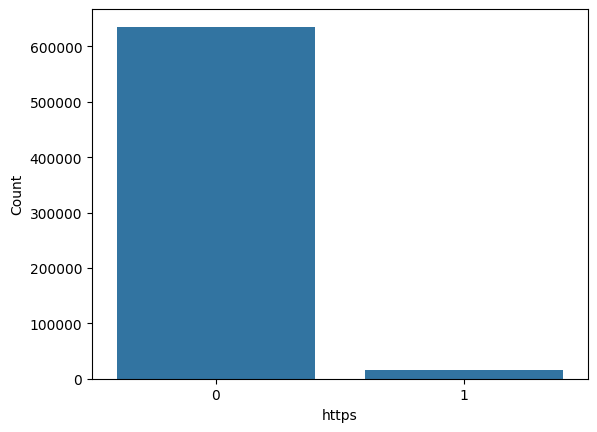

In [ ]:
count=df.https.value_counts()
sns.barplot(x=count.index, y=count)
plt.xlabel('https')
plt.ylabel('Count');

In [ ]:
def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits
df['digits']= df['url'].apply(lambda i: digit_count(i))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,#,%,+,$,!,*,",",//,https,digits
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,0,0,0,0,0,0,0,1,0,7
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,0,0,0,0,0,0,0,1,0,22


In [ ]:
def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters
df['letters']= df['url'].apply(lambda i: letter_count(i))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,%,+,$,!,*,",",//,https,digits,letters
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,0,0,0,0,0,0,13
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,0,0,0,0,0,0,1,29
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,0,0,0,0,0,0,1,25
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,0,0,0,0,0,1,0,7,63
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,0,0,0,0,0,1,0,22,199


In [ ]:
def Shortening_Service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)
    if match:
        return 1
    else:
        return 0
df['Shortening_Service'] = df['url'].apply(lambda x: Shortening_Service(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,+,$,!,*,",",//,https,digits,letters,Shortening_Service
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,0,0,0,0,0,13,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,0,0,0,0,0,1,29,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,0,0,0,0,0,1,25,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,0,0,0,0,1,0,7,63,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,0,0,0,0,1,0,22,199,0


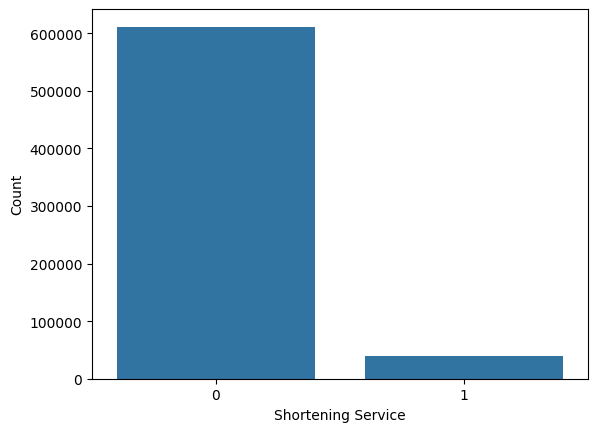

In [ ]:
count=df.Shortening_Service.value_counts()
sns.barplot(x=count.index, y=count)
plt.xlabel('Shortening Service')
plt.ylabel('Count');

In [ ]:
def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname = str(hostname)
    match = re.search(re.escape(hostname), url)
    if match:
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
df['Abnormal_URL'] = df['url'].apply(lambda x: abnormal_url(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,$,!,*,",",//,https,digits,letters,Shortening_Service,Abnormal_URL
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,0,0,0,0,13,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,0,0,0,0,1,29,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,0,0,0,0,1,25,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,0,0,0,1,0,7,63,0,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,0,0,0,1,0,22,199,0,1


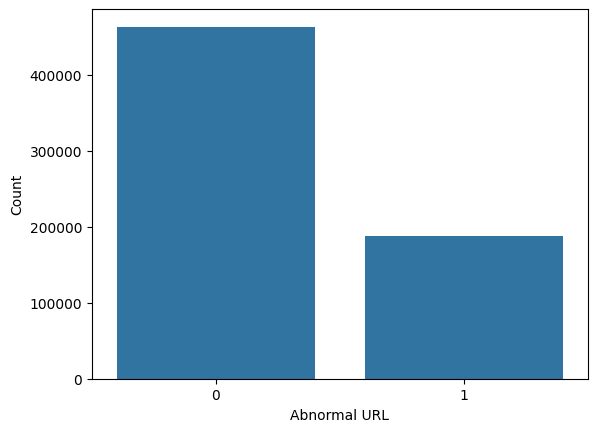

In [ ]:
count=df.Abnormal_URL.value_counts()
sns.barplot(x=count.index, y=count)
plt.xlabel('Abnormal URL')
plt.ylabel('Count');

In [ ]:
def is_url_ip_address(url: str) -> bool:
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4 with port
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}|'
        '([0-9]+(?:\.[0-9]+){3}:[0-9]+)|'
        '((?:(?:\d|[01]?\d\d|2[0-4]\d|25[0-5])\.){3}(?:25[0-5]|2[0-4]\d|[01]?\d\d|\d)(?:\/\d{1,2})?)', url)  # Ipv6
    if match:
        return 1
    else:
        return 0

df['is_ip'] = df['url'].apply(lambda i: is_url_ip_address(i))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,!,*,",",//,https,digits,letters,Shortening_Service,Abnormal_URL,is_ip
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,0,0,0,13,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,0,0,0,1,29,0,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,0,0,0,1,25,0,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,0,0,1,0,7,63,0,1,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,0,0,1,0,22,199,0,1,0


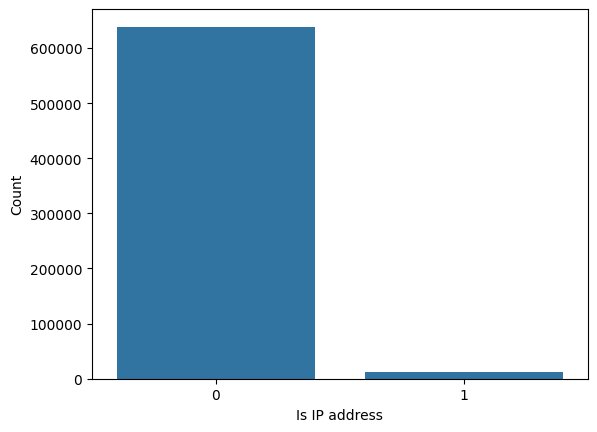

In [ ]:
count=df.is_ip.value_counts()
sns.barplot(x=count.index, y=count)
plt.xlabel('Is IP address')
plt.ylabel('Count');

In [ ]:
def get_url_path(url: str) :
    """
    Get's the path from a URL

    For example:

    If the URL was "www.google.co.uk/my/great/path"

    The path returned would be "my/great/path"
    """
    try:
        res = get_tld(url, as_object = True, fail_silently=False, fix_protocol=True)
        if res.parsed_url.query:
            joined = res.parsed_url.path + res.parsed_url.query
            return joined
        else:
            return res.parsed_url.path
    except:
        return None
df['url_path'] = df['url'].apply(lambda x: get_url_path(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,*,",",//,https,digits,letters,Shortening_Service,Abnormal_URL,is_ip,url_path
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,0,0,13,0,0,0,
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,0,0,1,29,0,0,0,/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,0,0,1,25,0,0,0,/rexroth/cr/1.htm
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,0,1,0,7,63,0,1,0,/index.phpoption=com_content&view=article&id=7...
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,0,1,0,22,199,0,1,0,/index.phpoption=com_mailto&tmpl=component&lin...


In [ ]:

df['url_path_len'] = df['url_path'].apply(lambda x: len(str(x)))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,",",//,https,digits,letters,Shortening_Service,Abnormal_URL,is_ip,url_path,url_path_len
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,0,13,0,0,0,,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,0,1,29,0,0,0,/music/krizz_kaliko.html,24
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,0,1,25,0,0,0,/rexroth/cr/1.htm,17
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,1,0,7,63,0,1,0,/index.phpoption=com_content&view=article&id=7...,59
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,1,0,22,199,0,1,0,/index.phpoption=com_mailto&tmpl=component&lin...,204


In [ ]:
def count_dir_in_url_path(url_path):
    """
    Counts number of / in url path to count number of
    sub directories
    """
    if url_path:
        n_dirs = url_path.count('/')
        return n_dirs
    else:
        return 0
df['count_dir_in_url_path'] = df['url_path'].apply(lambda x: count_dir_in_url_path(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,//,https,digits,letters,Shortening_Service,Abnormal_URL,is_ip,url_path,url_path_len,count_dir_in_url_path
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,0,13,0,0,0,,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,0,1,29,0,0,0,/music/krizz_kaliko.html,24,2
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,0,1,25,0,0,0,/rexroth/cr/1.htm,17,3
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,1,0,7,63,0,1,0,/index.phpoption=com_content&view=article&id=7...,59,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,1,0,22,199,0,1,0,/index.phpoption=com_mailto&tmpl=component&lin...,204,1


In [ ]:
def get_first_dir_len(url_path) :
    """
    Counts the length of the first directory within
    the URL provided
    """
    if url_path:
        if len(url_path.split('/')) > 1:
            first_dir_len = len(url_path.split('/')[1])
            return first_dir_len
    else:
        return 0
df['first_dir_len'] = df['url_path'].apply(lambda x: get_first_dir_len(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,https,digits,letters,Shortening_Service,Abnormal_URL,is_ip,url_path,url_path_len,count_dir_in_url_path,first_dir_len
0,br-icloud.com.br,phishing,2,16,br-icloud.com.br,0,0,1,0,2,...,0,0,13,0,0,0,,0,0,0.0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid.com,0,0,0,0,2,...,0,1,29,0,0,0,/music/krizz_kaliko.html,24,2,5.0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets.org,0,0,0,0,2,...,0,1,25,0,0,0,/rexroth/cr/1.htm,17,3,7.0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,www.garage-pirenne.be,0,1,1,4,3,...,0,7,63,0,1,0,/index.phpoption=com_content&view=article&id=7...,59,1,58.0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua.net,0,1,1,3,2,...,0,22,199,0,1,0,/index.phpoption=com_mailto&tmpl=component&lin...,204,1,203.0


In [ ]:
def process_tld(url: str, fix_protos: bool = False):
    """
    Takes a URL string and uses the tld library to extract subdomain, domain, top
    level domain and full length domain
    """
    res = get_tld(url, as_object = True, fail_silently=False, fix_protocol=fix_protos)

    subdomain = res.subdomain
    domain = res.domain
    tld = res.tld
    fld = res.fld

    return subdomain, domain, tld, fld

def process_url_with_tld(row: pd.Series):
    """
    Takes in a dataframe row, checks to see if rows `is_ip` column is
    False. If it is false, continues to process the URL and extract the
    features, otherwise sets four features to None before returning.

    This processing is wrapped in a try/except block to enable debugging
    and it prints out the inputs that caused a failure as well as a
    failure counter.
    """
    try:
        if row['is_ip'] == 0:
            if str(row['url']).startswith('http:'):
                return process_tld(row['url'])
            else:
                return process_tld(row['url'], fix_protos=True)
        else:
            subdomain = None
            domain = None
            tld = None
            fld = None
            return subdomain, domain, tld, fld
    except:
        idx = row.name
        url = row['url']
        type = row['type']
        print(f'Failed - {idx}: {url} is a {type} example')
        return None, None, None, None


df[['subdomain', 'domain', 'tld', 'fld']] = df.apply(lambda x: process_url_with_tld(x), axis=1, result_type="expand")



Failed - 555301: www.udc.an/wp-includes/js/tinymce/themes/advanced/img/link.htm is a benign example
Failed - 555675: www.udc.an/wp-includes/js/tinymce/themes/advanced/js/frm.htm is a benign example
Failed - 555800: 772050312/www1.royalbank.com/cgi-bin/rbaccess/rbunxcgi/ is a benign example
Failed - 567197: bin/webscr?cmd=_login- is a benign example
Failed - 573418: wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË
jlÛW¿]ø¾µj¿·ªo!ÒPì ·ÊïH§#'3ø@CÄRõ²çÇÝ®öQBÇÆg`ÈåZéê DîÂm®ÎÝQó*x;9?ÁÒâbùtÖÙ®mÞNP¯°^MQáSò°i°vþ[«³»]¹
(-§;¬ÔAèUèé\¨øíÌdB\[q½=ÿVuÃ»râæHäô/µ}»7!2=´ÂÏ4¿ª¡j91] is a phishing example
Failed - 573419: 'www.institutocgr.coo/web/media/syqvem/dk-óij!R\gr0âÕ5dfe<á<cmg&¤Gh!C<ò¡B-¨¨¼ ¬é'?l pýl ÖÒ%ÓaéþùkzHü]z?¹¯úT£bùÙî¬æÌì*UA×$Ë]õ³¯=Íÿ×ùÁÌý¡(~¶Ar¤÷G\$ðQñº¤KÎåcãÇ +¿Èôäþ(¹÷ sóQ¦NvO4zcÍÐGEõÂÚÃß=.¹ÏßZH{2-®tò¾VX©½½qx¼NÚPmødXæ&Ý»AnÂéa¶A¹®cÐBìß)aÚý^¨'JLî^ ¶ M¹´xxÃu4À@xýe^bÓ¡¹´ÞO7 is a phishing exampl

Failed - 587923: 0xdaf1be2b/EN/index.php is a benign example
Failed - 590597: bin/webscr?cmd=_login- is a benign example
Failed - 601516: 0x253BFC02/i/?zpgri&quot; is a benign example


In [ ]:
df['subdomain'].isna().sum()

12578

In [ ]:
df[['subdomain', 'domain', 'tld', 'fld']].isna().sum()[0] -  df['is_ip'].value_counts()[1]

90

In [ ]:
df.isna().sum()

url                          0
type                         0
Category                     0
url_len                      0
domain                   12578
@                            0
?                            0
-                            0
=                            0
.                            0
#                            0
%                            0
+                            0
$                            0
!                            0
*                            0
,                            0
//                           0
https                        0
digits                       0
letters                      0
Shortening_Service           0
Abnormal_URL                 0
is_ip                        0
url_path                 12217
url_path_len                 0
count_dir_in_url_path        0
first_dir_len               14
subdomain                12578
tld                      12578
fld                      12578
dtype: int64

In [ ]:
df[['subdomain', 'domain', 'tld', 'fld']].isna().sum(), df['is_ip'].value_counts()

(subdomain    12578
 domain       12578
 tld          12578
 fld          12578
 dtype: int64,
 0    638703
 1     12488
 Name: is_ip, dtype: int64)

In [ ]:
df[['subdomain', 'domain', 'tld', 'fld']].value_counts()

subdomain  domain               tld   fld                    
en         wikipedia            org   wikipedia.org              13206
           youtube              com   youtube.com                 8617
           facebook             com   facebook.com                7735
           amazon               com   amazon.com                  4618
           9779                 info  9779.info                   3984
                                                                 ...  
           montecassinosociety  org   montecassinosociety.org        1
           montecitoweddings    com   montecitoweddings.com          1
           montecristorecords   com   montecristorecords.com         1
           montega-uhren        ch    montega-uhren.ch               1
zzz        zggg                 com   zggg.com                       1
Length: 191417, dtype: int64

In [ ]:
df['subdomain_len'] = df['subdomain'].apply(lambda x: len(str(x)))
df['tld_len'] = df['tld'].apply(lambda x: len(str(x)))
df['fld_len'] = df['fld'].apply(lambda x: len(str(x)))

In [ ]:
df['url_puncs'] = (df['url_len'] - (df['letters'] + df['digits']))
# Binned Features
groups = ['Short', 'Medium', 'Long', 'Very Long']
# URL Lengths in 4 bins
df['url_len_q'] = pd.qcut(df['url_len'], q=4, labels=groups)
# FLD Lengths in 4 bins
df['fld_len_q'] = pd.qcut(df['fld_len'], q=4, labels=groups)

# Percentage Features
df['pc_alphas'] = df['letters'] / df['url_len']
df['pc_digits'] = df['digits'] / df['url_len']
df['pc_puncs'] = df['url_puncs'] / df['url_len']

# Added by sjy
df['hostname_len'] = df['subdomain_len'] + df['fld_len'] + 1

In [ ]:
df.to_csv('feature_extracted.csv')

In [ ]:
def url_has_port_in_string(url):
      has_port = urlparse(url).netloc.split(':')
      return len(has_port) > 1 and has_port[-1].isdigit()
df['has_port_no'] = df['url'].apply(lambda x: url_has_port_in_string(x))
df.head()


,url,type,Category,url_len,domain,@,?,-,=,.,...,tld_len,fld_len,url_puncs,url_len_q,fld_len_q,pc_alphas,pc_digits,pc_puncs,hostname_len,has_port_no
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,6,16,3,Short,Long,0.812500,0.000000,0.187500,17,False
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,3,11,5,Medium,Medium,0.828571,0.028571,0.142857,12,False
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,3,14,5,Short,Long,0.806452,0.032258,0.161290,15,False
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,2,17,18,Very Long,Long,0.715909,0.079545,0.204545,21,False
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,3,23,14,Very Long,Very Long,0.846809,0.093617,0.059574,24,False


In [ ]:
df['has_port_no'].value_counts()

False    646234
True       4957
Name: has_port_no, dtype: int64

In [ ]:
def number_of_parameters(url):
      params = urlparse(url).query
      return 0 if params == '' else len(params.split('&'))
df['number_of_params'] = df['url'].apply(lambda x: number_of_parameters(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,fld_len,url_puncs,url_len_q,fld_len_q,pc_alphas,pc_digits,pc_puncs,hostname_len,has_port_no,number_of_params
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,16,3,Short,Long,0.812500,0.000000,0.187500,17,False,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,11,5,Medium,Medium,0.828571,0.028571,0.142857,12,False,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,14,5,Short,Long,0.806452,0.032258,0.161290,15,False,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,17,18,Very Long,Long,0.715909,0.079545,0.204545,21,False,4
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,23,14,Very Long,Very Long,0.846809,0.093617,0.059574,24,False,3


In [ ]:
def number_of_fragments(url):
    frags = urlparse(url).fragment
    if frags:
        # If there are fragments, count them by splitting on '#'
        return len(frags.split('#'))
    else:
        # If there are no fragments, return 0
        return 0

df['number_of_fragments'] = df['url'].apply(lambda x: number_of_fragments(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,url_puncs,url_len_q,fld_len_q,pc_alphas,pc_digits,pc_puncs,hostname_len,has_port_no,number_of_params,number_of_fragments
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,3,Short,Long,0.812500,0.000000,0.187500,17,False,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,5,Medium,Medium,0.828571,0.028571,0.142857,12,False,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,5,Short,Long,0.806452,0.032258,0.161290,15,False,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,18,Very Long,Long,0.715909,0.079545,0.204545,21,False,4,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,14,Very Long,Very Long,0.846809,0.093617,0.059574,24,False,3,0


In [ ]:
df['number_of_fragments'].value_counts()

0    650730
1       440
2        14
3         4
5         1
4         1
6         1
Name: number_of_fragments, dtype: int64

In [ ]:

def has_client_in_string(url):
    return 'client' in url.lower()

def has_admin_in_string(url):
    return 'admin' in url.lower()

def has_server_in_string(url):
    return 'server' in url.lower()

def has_login_in_string(url):
    return 'login' in url.lower()

df['has_client'] = df['url'].apply(lambda x: has_client_in_string(x))
df['has_admin'] = df['url'].apply(lambda x: has_admin_in_string(x))
df['has_server'] = df['url'].apply(lambda x: has_server_in_string(x))
df['has_login'] = df['url'].apply(lambda x: has_login_in_string(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,pc_digits,pc_puncs,hostname_len,has_port_no,number_of_params,number_of_fragments,has_client,has_admin,has_server,has_login
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,0.000000,0.187500,17,False,0,0,False,False,False,False
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,0.028571,0.142857,12,False,0,0,False,False,False,False
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,0.032258,0.161290,15,False,0,0,False,False,False,False
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,0.079545,0.204545,21,False,4,0,False,False,False,False
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,0.093617,0.059574,24,False,3,0,False,False,False,False


In [ ]:
df['has_client'].value_counts()

False    649925
True       1266
Name: has_client, dtype: int64

In [ ]:
df['has_server'].value_counts()

False    649778
True       1413
Name: has_server, dtype: int64

In [ ]:
df['has_admin'].value_counts()

False    648453
True       2738
Name: has_admin, dtype: int64

In [ ]:
df['has_login'].value_counts()

False    630495
True      20696
Name: has_login, dtype: int64

In [ ]:
def __get_entropy(text):
        text = text.lower()
        probs = [text.count(c) / len(text) for c in set(text)]
        entropy = -sum([p * log(p) / log(2.0) for p in probs])
        return entropy
def url_string_entropy(url):
        return __get_entropy(url)
df['entropy_of_url'] = df['url'].apply(lambda x: url_string_entropy(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,pc_puncs,hostname_len,has_port_no,number_of_params,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,0.187500,17,False,0,0,False,False,False,False,3.375000
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,0.142857,12,False,0,0,False,False,False,False,4.079143
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,0.161290,15,False,0,0,False,False,False,False,3.708093
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,0.204545,21,False,4,0,False,False,False,False,4.660343
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,0.059574,24,False,3,0,False,False,False,False,4.980518


In [ ]:
def subdomain_string_entropy(subdomain):
        if subdomain!=None:
          return __get_entropy(subdomain)
        else:
          return 0
df['entropy_of_subdomain'] = df['subdomain'].apply(lambda x: subdomain_string_entropy(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,hostname_len,has_port_no,number_of_params,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url,entropy_of_subdomain
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,17,False,0,0,False,False,False,False,3.375000,0.0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,12,False,0,0,False,False,False,False,4.079143,0.0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,15,False,0,0,False,False,False,False,3.708093,0.0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,21,False,4,0,False,False,False,False,4.660343,-0.0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,24,False,3,0,False,False,False,False,4.980518,0.0


In [ ]:
def domain_string_entropy(domain):
        if domain!=None:
          return __get_entropy(domain)
        else:
          return 0
df['entropy_of_domain'] = df['domain'].apply(lambda x: domain_string_entropy(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,has_port_no,number_of_params,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url,entropy_of_subdomain,entropy_of_domain
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,False,0,0,False,False,False,False,3.375000,0.0,3.169925
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,False,0,0,False,False,False,False,4.079143,0.0,2.807355
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,False,0,0,False,False,False,False,3.708093,0.0,2.921928
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,False,4,0,False,False,False,False,4.660343,-0.0,2.896292
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,False,3,0,False,False,False,False,4.980518,0.0,3.405822


In [ ]:
def tld_string_entropy(tld):
        if tld!=None:
          return __get_entropy(tld)
        else:
          return 0
df['entropy_of_tld'] = df['tld'].apply(lambda x: tld_string_entropy(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,number_of_params,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url,entropy_of_subdomain,entropy_of_domain,entropy_of_tld
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,0,0,False,False,False,False,3.375000,0.0,3.169925,2.584963
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,0,0,False,False,False,False,4.079143,0.0,2.807355,1.584963
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,0,0,False,False,False,False,3.708093,0.0,2.921928,1.584963
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,4,0,False,False,False,False,4.660343,-0.0,2.896292,1.000000
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,3,0,False,False,False,False,4.980518,0.0,3.405822,1.584963


In [ ]:
def fld_string_entropy(fld):
        if fld!=None:
          return __get_entropy(fld)
        else:
          return 0
df['entropy_of_fld'] = df['fld'].apply(lambda x: fld_string_entropy(x))
df.head()

,url,type,Category,url_len,domain,@,?,-,=,.,...,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url,entropy_of_subdomain,entropy_of_domain,entropy_of_tld,entropy_of_fld
0,br-icloud.com.br,phishing,2,16,br-icloud,0,0,1,0,2,...,0,False,False,False,False,3.375000,0.0,3.169925,2.584963,3.375000
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,mp3raid,0,0,0,0,2,...,0,False,False,False,False,4.079143,0.0,2.807355,1.584963,3.277613
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,bopsecrets,0,0,0,0,2,...,0,False,False,False,False,3.708093,0.0,2.921928,1.584963,3.235926
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,garage-pirenne,0,1,1,4,3,...,0,False,False,False,False,4.660343,-0.0,2.896292,1.000000,3.146286
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,adventure-nicaragua,0,1,1,3,2,...,0,False,False,False,False,4.980518,0.0,3.405822,1.584963,3.501398


In [ ]:
df1= df.copy()

In [ ]:
# Define a list of suspicious punctuations
suspicious_punctuations = ['@', '#', '?', '!', '%', '$', '&', '=', '*', '+', ',', ';', '`', '~']

def count_suspicious_punctuations(url):
    return sum(url.count(punc) for punc in suspicious_punctuations)

df1['num_suspicious_punctuations'] = df1['url'].apply(count_suspicious_punctuations)

In [ ]:
admin_terms = ['admin', 'administrator', 'manage', 'manager', 'root', 'control', 'panel', 'cpanel']

def contains_admin_terms(url):
    url_lower = url.lower()  # Convert to lowercase for case-insensitive matching
    return any(term in url_lower for term in admin_terms)
df1['contains_admin_terms'] = df1['url'].apply(contains_admin_terms).astype(int)

In [ ]:
login_terms = ['login', 'signin', 'logon', 'auth', 'account', 'user', 'password']

def contains_login_terms(url):
    url_lower = url.lower()  # Convert to lowercase for case-insensitive matching
    return any(term in url_lower for term in login_terms)

df1['contains_login_terms'] = df1['url'].apply(contains_login_terms).astype(int)

In [ ]:
server_terms = ['server', 'srv', 'host', 'node', 'backend', 'cluster']

def contains_server_terms(url):
    url_lower = url.lower()  # Convert to lowercase for case-insensitive matching
    return any(term in url_lower for term in server_terms)

df1['contains_server_terms'] = df1['url'].apply(contains_server_terms).astype(int)

In [ ]:
client_terms = ['client', 'customer', 'user', 'consumer', 'cust']

def contains_client_terms(url):
    url_lower = url.lower()  # Convert to lowercase for case-insensitive matching
    return any(term in url_lower for term in client_terms)

df1['contains_client_terms'] = df1['url'].apply(contains_client_terms).astype(int)

In [ ]:
def digit_to_alphabet_ratio(url):
    num_digits = sum(c.isdigit() for c in url)
    num_alphabets = sum(c.isalpha() for c in url)
    # Avoid division by zero
    return num_digits / num_alphabets if num_alphabets > 0 else 0

df1['digit_to_alphabet_ratio'] = df1['url'].apply(digit_to_alphabet_ratio)

In [ ]:
def special_character_to_length_ratio(url):
    total_length = len(url)
    num_special_chars = sum(not c.isalnum() for c in url)  # Count characters that are not alphanumeric
    # Avoid division by zero
    return num_special_chars / total_length if total_length > 0 else 0

df1['special_character_to_length_ratio'] = df1['url'].apply(special_character_to_length_ratio)

In [ ]:
from urllib.parse import urlparse

def query_to_domain_ratio(url):
    parsed_url = urlparse(url)
    query_length = len(parsed_url.query)  # Length of the query string
    domain_length = len(parsed_url.netloc)  # Length of the domain (hostname)
    # Avoid division by zero
    return query_length / domain_length if domain_length > 0 else 0

df1['query_to_domain_ratio'] = df1['url'].apply(query_to_domain_ratio)

In [ ]:
def num_subdomains(url):
    parsed_url = urlparse(url)
    domain_parts = parsed_url.netloc.split('.')
    # Count all parts of the domain except for the top-level domain (TLD) and main domain
    # Example: "sub1.sub2.example.com" -> 2 subdomains ("sub1" and "sub2")
    return len(domain_parts) - 2 if len(domain_parts) > 2 else 0

df1['num_subdomains'] = df1['url'].apply(num_subdomains)

In [ ]:
def longest_subdomain_length(url):
    parsed_url = urlparse(url)
    domain_parts = parsed_url.netloc.split('.')
    # Exclude the main domain and TLD; focus only on subdomains
    subdomains = domain_parts[:-2] if len(domain_parts) > 2 else []
    # Return the length of the longest subdomain or 0 if there are no subdomains
    return max(len(subdomain) for subdomain in subdomains) if subdomains else 0

df1['longest_subdomain_length'] = df1['url'].apply(longest_subdomain_length)

In [ ]:
# Example blacklist and whitelist
blacklist = ['malicious.com', 'phishing-site.com', 'suspicious.net']
whitelist = ['example.com', 'trusted-site.org', 'safewebsite.net']

def domain_reputation_flag(url):
    parsed_url = urlparse(url)
    domain = parsed_url.netloc
    if domain in blacklist:
        return -1  # Domain is in the blacklist (bad reputation)
    elif domain in whitelist:
        return 1  # Domain is in the whitelist (good reputation)
    else:
        return 0  # Domain is not in either list (unknown reputation)

df1['domain_reputation_flag'] = df1['url'].apply(domain_reputation_flag)

In [ ]:
suspicious_keywords = [
    'free', 'offer', 'win', 'winner', 'cash', 'bonus', 'prize', 'discount',
    'earn', 'lottery', 'gift', 'promo', 'click', 'validate', 'verify',
    'urgent', 'claim', 'exclusive', 'guarantee', 'limited', 'cheap', 'pay',
    'account', 'secure', 'login', 'signin', 'reset'
]

def suspicious_keyword_count(url):
    url_lower = url.lower()  # Convert URL to lowercase for case-insensitive matching
    return sum(keyword in url_lower for keyword in suspicious_keywords)

df1['suspicious_keyword_count'] = df1['url'].apply(suspicious_keyword_count)

In [ ]:
import re

def hexadecimal_pattern_count(url):
    # Regular expression to match hexadecimal patterns
    hex_pattern = r'\b[0-9a-fA-F]{2,}\b'
    # Find all matches of hexadecimal patterns
    matches = re.findall(hex_pattern, url)
    return len(matches)

df1['hexadecimal_pattern_count'] = df1['url'].apply(hexadecimal_pattern_count)

In [ ]:
suspicious_terms = ['%20', 'script', 'eval', 'base64', 'alert', 'onclick', 'onerror', 'iframe', '<img', '<svg', 'javascript', 'cookie', 'session']

def contains_suspicious_terms(url):
    url_lower = url.lower()  # Convert to lowercase for case-insensitive matching
    return any(term in url_lower for term in suspicious_terms)

df1['contains_suspicious_terms'] = df1['url'].apply(contains_suspicious_terms).astype(int)

In [ ]:
def has_http(url):
    return 1 if url.lower().startswith('http://') else 0

df1['has_http'] = df1['url'].apply(has_http)

In [ ]:
from collections import Counter
from math import log2

def calculate_entropy(string):
    if not string:  # Handle empty strings
        return 0
    frequency = Counter(string)
    total_length = len(string)
    return -sum((count / total_length) * log2(count / total_length) for count in frequency.values())

def path_entropy(url):
    parsed_url = urlparse(url)
    return calculate_entropy(parsed_url.path)

df1['path_entropy'] = df1['url'].apply(path_entropy)

In [ ]:
from urllib.parse import urlparse

def domain_to_url_ratio(url):
    parsed_url = urlparse(url)
    domain_length = len(parsed_url.netloc)  # Length of the domain (hostname)
    url_length = len(url)  # Total length of the URL
    # Avoid division by zero
    return domain_length / url_length if url_length > 0 else 0

df1['domain_to_url_ratio'] = df1['url'].apply(domain_to_url_ratio)

In [ ]:
def path_to_url_ratio(url):
    parsed_url = urlparse(url)
    path_length = len(parsed_url.path)  # Length of the path component
    url_length = len(url)  # Total length of the URL
    # Avoid division by zero
    return path_length / url_length if url_length > 0 else 0

df1['path_to_url_ratio'] = df1['url'].apply(path_to_url_ratio)

In [ ]:
def query_to_url_ratio(url):
    parsed_url = urlparse(url)
    query_length = len(parsed_url.query)  # Length of the query component
    url_length = len(url)  # Total length of the URL
    # Avoid division by zero
    return query_length / url_length if url_length > 0 else 0

df1['query_to_url_ratio'] = df1['url'].apply(query_to_url_ratio)

In [ ]:
def percent_special_chars(url):
    total_length = len(url)  # Total length of the URL
    num_special_chars = sum(not c.isalnum() for c in url)  # Count special characters (non-alphanumeric)
    # Avoid division by zero
    return (num_special_chars / total_length) * 100 if total_length > 0 else 0

df1['percent_special_chars'] = df1['url'].apply(percent_special_chars)

In [ ]:
def percent_uppercase(url):
    total_length = len(url)  # Total length of the URL
    num_uppercase = sum(c.isupper() for c in url)  # Count uppercase letters
    # Avoid division by zero
    return (num_uppercase / total_length) * 100 if total_length > 0 else 0

df1['percent_uppercase'] = df1['url'].apply(percent_uppercase)

In [ ]:
def percent_lowercase(url):
    total_length = len(url)  # Total length of the URL
    num_lowercase = sum(c.islower() for c in url)  # Count lowercase letters
    # Avoid division by zero
    return (num_lowercase / total_length) * 100 if total_length > 0 else 0

df1['percent_lowercase'] = df1['url'].apply(percent_lowercase)

In [ ]:
def url_length(url):
    return len(url)

df1['url_length'] = df1['url'].apply(url_length)

In [ ]:
def domain_length(url):
    parsed_url = urlparse(url)
    return len(parsed_url.netloc)  # Length of the hostname (domain)


df1['domain_length'] = df1['url'].apply(domain_length)

In [ ]:
def num_directories(url):
    parsed_url = urlparse(url)
    path = parsed_url.path.strip('/')  # Remove leading and trailing slashes
    directories = path.split('/')  # Split the path into directories
    return len(directories) if path else 0  # Return the count of directories, or 0 if no path

df1['num_directories'] = df1['url'].apply(num_directories)

In [ ]:
from urllib.parse import urlparse, parse_qs

def num_query_params(url):
    parsed_url = urlparse(url)
    query_params = parse_qs(parsed_url.query)  # Parse the query string into a dictionary
    return len(query_params)  # Count the number of query parameters


df1['num_query_params'] = df1['url'].apply(num_query_params)

In [ ]:
df1['is_long_url'] = (df1['url_length'] > 75).astype(int)

In [ ]:
df1['high_entropy_url'] = (df1['entropy_of_url'] > 3).astype(int)

In [ ]:
df1['has_special_chars'] = (df1['url_puncs'] > 5).astype(int)

In [ ]:
df1['len_x_digits'] = df1['url_length'] * df1['digits']

In [ ]:
df1['len_x_letters'] = df1['url_length'] * df1['letters']

In [ ]:
df1['path_depth_ratio'] = df1['count_dir_in_url_path'] / (df1['url_path_len'] + 1e-5)

In [ ]:
from math import log

def combined_entropy(col1, col2):
    combined = col1 + col2
    if combined != 0:
        prob = col1 / combined
        return -(prob * log(prob + 1e-5, 2))
    return 0

df1['entropy_len_digits'] = df1.apply(
    lambda row: combined_entropy(row['url_length'], row['digits']), axis=1
)
df1['entropy_len_puncs'] = df1.apply(
    lambda row: combined_entropy(row['url_length'], row['url_puncs']), axis=1
)

In [ ]:
df1['len_div_digits'] = df1['url_length'] / (df1['digits'] + 1e-5)

In [ ]:
df1['letters_div_digits'] = df1['letters'] / (df1['digits'] + 1e-5)
df1['puncs_x_digits'] = df1['url_puncs'] * df1['digits']
df1['len_div_puncs'] = df1['url_length'] / (df1['url_puncs'] + 1e-5)
df1['subdomain_x_tld'] = df1['subdomain_len'] * df1['tld_len']

In [ ]:
df1['has_multiple_tlds'] = df1['url'].apply(lambda x: int(x.count('.') > 2))

In [ ]:
df1['is_generic_tld'] = df1['tld'].apply(lambda x: int(x in ['com', 'org', 'net', 'info']))

In [ ]:
df1['has_www'] = df1['url'].apply(lambda x: int('www.' in x))

In [ ]:
from urllib.parse import urlparse

def extract_tld(url):
    parsed_url = urlparse(url)
    domain_parts = parsed_url.netloc.split('.')
    return domain_parts[-1] if len(domain_parts) > 1 else ''

# df['tld'] = df['url'].apply(extract_tld)  # Replace 'url_column' with your URL column name

df1['is_numeric_tld'] = df1['tld'].apply(lambda x: int(str(x).isdigit()))

In [ ]:
df1['count_slashes'] = df1['url'].str.count('/')

In [ ]:
df1['count_underscore'] = df1['url'].str.count('_')

In [ ]:
df1['count_uppercase'] = df1['url'].str.count(r'[A-Z]')
df1['count_lowercase'] = df1['url'].str.count(r'[a-z]')

In [ ]:
df1['word_count'] = df1['url'].apply(lambda x: len(x.split('/')))

In [ ]:
df1['avg_word_len'] = df1['url'].apply(lambda x: np.mean([len(word) for word in x.split('/')]))

In [ ]:
phishing_keywords = ['verify', 'secure', 'bank', 'account', 'free', 'offer']
for keyword in phishing_keywords:
    df1[f'contains_{keyword}'] = df1['url'].apply(lambda x: int(keyword in x.lower()))

In [ ]:
df1['is_long_subdomain'] = (df1['subdomain_len'] > 10).astype(int)

In [ ]:
columns_to_roll = ['url_length', 'letters', 'digits', 'url_puncs']
for col in columns_to_roll:
    df1[f'{col}_rolling_mean'] = df1[col].rolling(window=5, min_periods=1).mean()
    df1[f'{col}_rolling_std'] = df1[col].rolling(window=5, min_periods=1).std()

for col in columns_to_roll:
    df1[f'{col}_rank'] = df1[col].rank()

In [ ]:
def extract_subdomain(url):
    parsed_url = urlparse(url)
    domain_parts = parsed_url.netloc.split('.')
    # Subdomain is everything before the main domain and TLD
    return '.'.join(domain_parts[:-2]) if len(domain_parts) > 2 else ''

# Add a subdomain column
# df['subdomain'] = df['url'].apply(extract_subdomain)

# Create the has_suspicious_subdomain feature
suspicious_words = ['update', 'secure', 'login', 'verify']
df1['has_suspicious_subdomain'] = df1['subdomain'].apply(
    lambda x: int(any(word in str(x).lower() for word in suspicious_words))
)

In [ ]:
df1['is_commercial_tld'] = df1['tld'].apply(lambda x: int(str(x).lower() in ['com', 'biz', 'co']))
df1['is_nonprofit_tld'] = df1['tld'].apply(lambda x: int(str(x).lower() in ['org', 'edu']))
df1['is_country_code_tld'] = df1['tld'].apply(lambda x: int(str(x).lower() in ['uk', 'in', 'us', 'de', 'fr']))

In [ ]:
df1['has_multiple_fragments'] = (df1['number_of_fragments'] > 1).astype(int)
df1['has_multiple_parameters'] = (df1['number_of_params'] > 1).astype(int)

In [ ]:
df1['has_admin_and_suspicious'] = df1['has_admin'] & df1['has_suspicious_subdomain']
df1['has_login_and_high_entropy'] = df1['has_login'] & (df1['entropy_of_url'] > 3.5)

In [ ]:
df1['longest_path_segment'] = df1['url_path'].apply(lambda x: max([len(seg) for seg in str(x).split('/')]) if x else 0)

In [ ]:
df1['numeric_subdomains_count'] = df1['subdomain'].apply(lambda x: sum(1 for sub in str(x).split('.') if sub.isdigit()))

In [ ]:
df1['capitalization_ratio'] = df1['url'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1e-5))

In [ ]:
df_final=df.drop(['domain','url_path','subdomain','url','tld','fld'],axis=1,inplace=False )

In [ ]:
import re
df1['repetitive_char_count'] = df1['url'].apply(lambda x: len(re.findall(r'(.)\1{2,}', x)))

In [ ]:
non_standard_tlds = ['xyz', 'club', 'site', 'online', 'top']
df1['is_non_standard_tld'] = df1['tld'].apply(lambda x: int(str(x).lower() in non_standard_tlds))

In [ ]:
spam_keywords = ['win', 'prize', 'cash', 'lottery', 'offer']
df1['spam_keyword_count'] = df1['url'].apply(lambda x: sum(1 for word in spam_keywords if word in x.lower()))

In [ ]:
df1['brand_mismatch_flag'] = df1.apply(lambda x: int(str(x['domain']).split('.')[0].lower() not in x['url']), axis=1)

In [ ]:
suspicious_extensions = ['exe', 'zip', 'apk', 'bat', 'scr']
df1['has_suspicious_extension'] = df1['url'].apply(lambda x: int(any(x.lower().endswith(ext) for ext in suspicious_extensions)))

In [ ]:
import nltk
nltk.download('words')
from nltk.corpus import words
english_words = set(words.words())
df1['domain_is_english'] = df1['domain'].apply(lambda x: int(any(part in english_words for part in str(x).split('.'))))

[nltk_data] Downloading package words to /Users/hinjam/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:
popular_domains = ['google.com', 'facebook.com', 'youtube.com']
df1['is_popular_domain'] = df1['domain'].apply(lambda x: int(x in popular_domains))

In [ ]:
# import requests

# def get_redirect_count(url):
#     try:
#         if 'http' in url:
#             response = requests.get(url, timeout=5)  # Add a timeout to avoid hanging requests
#             return len(response.history)
#         return 0
#     except requests.exceptions.RequestException:
#         # Catch any exception raised by ⁠ requests ⁠ (e.g., connection issues, timeout)
#         return -1  # Use -1 to indicate that the request failed

# df['redirect_count'] = df['url'].apply(get_redirect_count)

In [ ]:
# Expanded list of time-related patterns
time_patterns = [
    # Years
    '2023', '2024', '2025', '2026',
    # Months (full names and abbreviations)
    'january', 'february', 'march', 'april', 'may', 'june', 'july',
    'august', 'september', 'october', 'november', 'december',
    'jan', 'feb', 'mar', 'apr', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec',
    # Seasons
    'spring', 'summer', 'fall', 'autumn', 'winter',
    # Common time periods
    'week', 'day', 'hour', 'minute', 'second', 'today', 'yesterday', 'tomorrow',
    'now', 'soon', 'next', 'prev', 'past',
    # Quarters
    'q1', 'q2', 'q3', 'q4',
    # Other temporal keywords
    'midnight', 'morning', 'noon', 'afternoon', 'evening', 'night',
    '24h', '12h', 'am', 'pm'
]



df1['contains_time_pattern'] = df1['domain'].apply(
    lambda x: int(any(term in str(x).lower() for term in time_patterns)) if pd.notnull(x) else 0
)

In [ ]:
from difflib import SequenceMatcher

# Ensure domain and subdomain are strings and handle None/NaN
df1['domain_similarity_score'] = df1.apply(
    lambda x: SequenceMatcher(None, str(x['domain'] or ''), str(x['subdomain'] or '')).ratio(), axis=1
)

In [ ]:
df1['path_segment_entropy'] = df1['url_path'].apply(lambda x: np.mean([__get_entropy(seg) for seg in str(x).split('/')]) if x else 0)

In [ ]:
import requests

In [ ]:
# def has_external_scripts(url):
#     try:
#         r = requests.get(url)
#         return int('src=' in r.text.lower())
#     except:
#         return 0
# df['external_scripts'] = df['url'].apply(has_external_scripts)



In [ ]:
df1['has_https'] = df1['url'].apply(lambda x: int('https://' in str(x)))

In [ ]:
#df['has_unusual_subdomain'] = df['subdomain'].apply(lambda x: int('--' in x))
df1['has_unusual_subdomain'] = df1['subdomain'].apply(lambda x: int('--' in str(x) if x else False))

In [ ]:
import base64
def is_base64(s):
    try:
        return base64.b64encode(base64.b64decode(s)).decode() == s
    except:
        return False
df1['contains_base64'] = df1['url'].apply(lambda x: int(any(is_base64(part) for part in x.split('?')[-1].split('&'))))

In [ ]:
#df['median_word_length_path'] = df['url_path'].apply(lambda x: np.median([len(word) for word in x.split('/') if word]))
df1['median_word_length_path'] = df1['url_path'].apply(
    lambda x: np.median([len(word) for word in str(x).split('/') if word]) if x else 0
)

/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [ ]:
def compute_cdi(url):
    # Count the number of unique characters
    unique_chars = len(set(url))
    # Calculate the Character Diversity Index
    return unique_chars / (len(url) + 1e-5)  # Add a small value to avoid division by zero

# Apply the CDI computation to the dataframe
df1['character_diversity_index'] = df1['url'].apply(compute_cdi)

In [ ]:
import math

def keyword_context_entropy(url):
    # Split the URL path into keywords
    path = urlparse(url).path
    keywords = [word for word in re.split(r'[\/\-\_\.\+]', path) if word]
    if not keywords:
        return 0
    # Count occurrences of each keyword
    keyword_counts = {word: keywords.count(word) for word in keywords}
    total_keywords = len(keywords)
    # Compute entropy
    entropy = -sum((count / total_keywords) * math.log2(count / total_keywords)
                   for count in keyword_counts.values())
    return entropy

# Apply to the dataset
df1['keyword_context_entropy'] = df1['url'].apply(keyword_context_entropy)


In [ ]:
def max_consecutive_symbols(url):
    # Find all consecutive symbol sequences
    symbol_sequences = re.findall(r'[^a-zA-Z0-9]+', url)
    # Return the length of the longest sequence
    return max((len(seq) for seq in symbol_sequences), default=0)

# Apply to the dataset
df1['max_consecutive_symbols'] = df1['url'].apply(max_consecutive_symbols)


In [ ]:
homoglyphs = {'0', 'O', 'o', '1', 'l', 'I', 'S', '5', '@', 'a', '3', 'E'}

def count_homoglyphs(url):
    count = sum(1 for c in url if c in homoglyphs)
    return count

df1['homoglyph_count'] = df1['url'].apply(count_homoglyphs)

In [ ]:
df1.to_csv('all_feature_extracted.csv')

In [ ]:
df_final1=df1.drop(['domain','url_path','subdomain','url','tld','fld'],axis=1,inplace=False )

In [ ]:
df_final1['url_len_q'] = df_final1['url_len_q'].cat.codes
df_final1['fld_len_q'] = df_final1['fld_len_q'].cat.codes

In [ ]:
X=df_final1.drop(['Category','type'], axis=1)
print(X.dtypes)

y = df_final1['Category']

url_len                        int64
@                              int64
?                              int64
-                              int64
=                              int64
                              ...   
median_word_length_path      float64
character_diversity_index    float64
keyword_context_entropy      float64
max_consecutive_symbols        int64
homoglyph_count                int64
Length: 142, dtype: object


In [ ]:
# Identify columns with float type
float_columns = X.select_dtypes(include=['float']).columns

# Print the float columns
print("Float columns:")
print(float_columns)

# Drop the float columns
X = X.drop(columns=float_columns)

# Confirm the updated DataFrame
print("\nUpdated DataFrame:")
print(X.dtypes)


Float columns:
Index(['first_dir_len', 'pc_alphas', 'pc_digits', 'pc_puncs', 'entropy_of_url',
       'entropy_of_subdomain', 'entropy_of_domain', 'entropy_of_tld',
       'entropy_of_fld', 'digit_to_alphabet_ratio',
       'special_character_to_length_ratio', 'query_to_domain_ratio',
       'path_entropy', 'domain_to_url_ratio', 'path_to_url_ratio',
       'query_to_url_ratio', 'percent_special_chars', 'percent_uppercase',
       'percent_lowercase', 'path_depth_ratio', 'entropy_len_digits',
       'entropy_len_puncs', 'len_div_digits', 'letters_div_digits',
       'len_div_puncs', 'avg_word_len', 'url_length_rolling_mean',
       'url_length_rolling_std', 'letters_rolling_mean', 'letters_rolling_std',
       'digits_rolling_mean', 'digits_rolling_std', 'url_puncs_rolling_mean',
       'url_puncs_rolling_std', 'url_length_rank', 'letters_rank',
       'digits_rank', 'url_puncs_rank', 'capitalization_ratio',
       'domain_similarity_score', 'path_segment_entropy',
       'median_word_

In [ ]:
###Random Forest feature Importances

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

Feature_importances = rf.feature_importances_
features = X.columns
sorted_indices = np.argsort(Feature_importances)

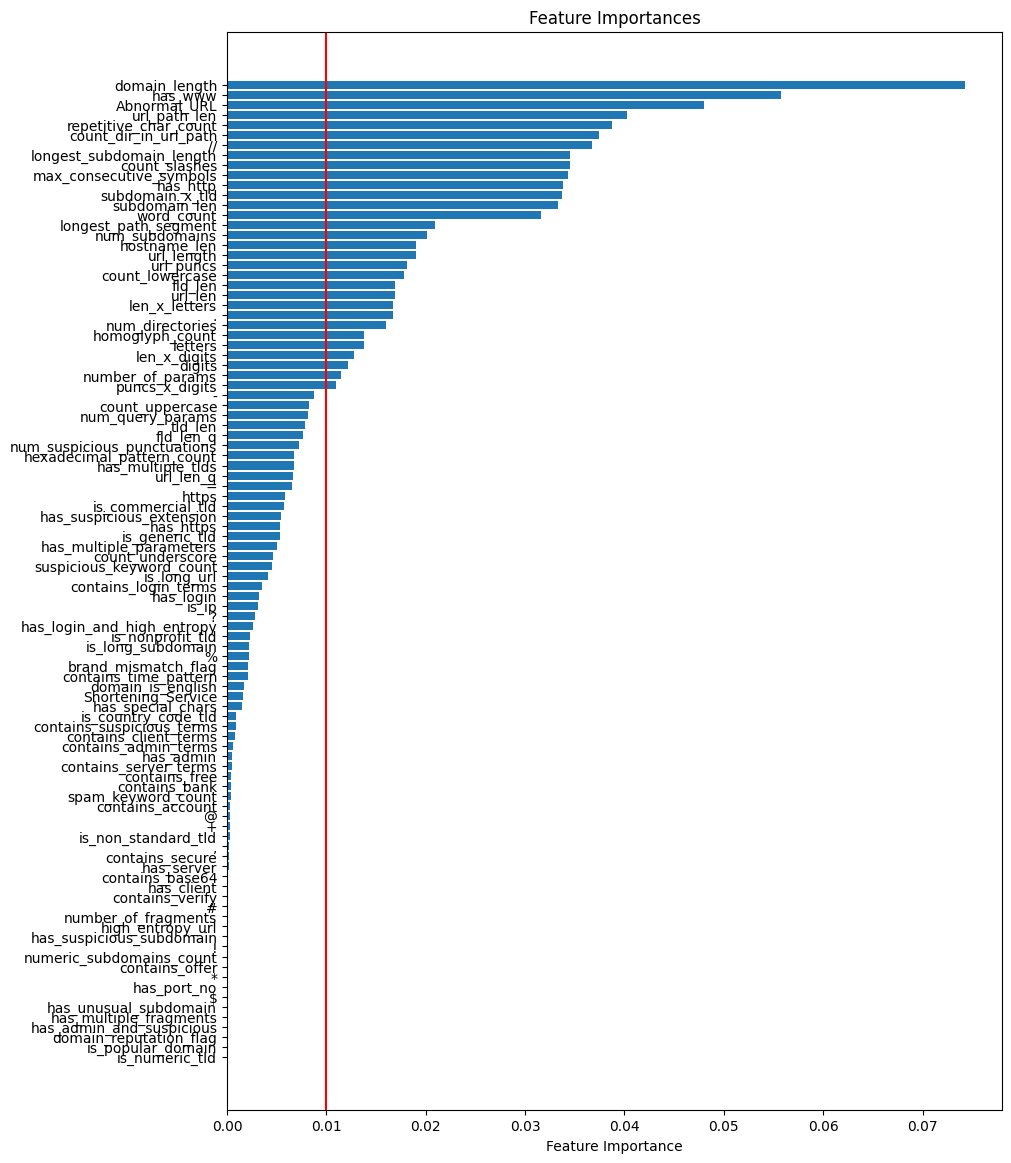

Eliminated Features:
['@', '?', '-', '=', '#', '%', '+', '$', '!', '*', ',', 'https', 'Shortening_Service', 'is_ip', 'tld_len', 'url_len_q', 'fld_len_q', 'has_port_no', 'number_of_fragments', 'has_client', 'has_admin', 'has_server', 'has_login', 'num_suspicious_punctuations', 'contains_admin_terms', 'contains_login_terms', 'contains_server_terms', 'contains_client_terms', 'domain_reputation_flag', 'suspicious_keyword_count', 'hexadecimal_pattern_count', 'contains_suspicious_terms', 'num_query_params', 'is_long_url', 'high_entropy_url', 'has_special_chars', 'has_multiple_tlds', 'is_generic_tld', 'is_numeric_tld', 'count_underscore', 'count_uppercase', 'contains_verify', 'contains_secure', 'contains_bank', 'contains_account', 'contains_free', 'contains_offer', 'is_long_subdomain', 'has_suspicious_subdomain', 'is_commercial_tld', 'is_nonprofit_tld', 'is_country_code_tld', 'has_multiple_fragments', 'has_multiple_parameters', 'has_admin_and_suspicious', 'has_login_and_high_entropy', 'numeri

In [ ]:
threshold = 0.01
plt.figure(figsize=(10, 14))

plt.barh(range(X.shape[1]), Feature_importances[sorted_indices], align='center')
plt.axvline(x=threshold, color='r', linestyle='-')
plt.yticks(range(X.shape[1]), [features[i] for i in sorted_indices])
plt.xlabel('Feature Importance')
plt.title('Feature Importances')
plt.savefig('Feature_importances.jpg',dpi=300)
plt.show()



selected_features_rf=[]
eliminated_features_rf=[]

for feature, importance in zip(features,Feature_importances):
    if importance>threshold:
        selected_features_rf.append(feature)
    else:
        eliminated_features_rf.append(feature)

print("Eliminated Features:")
print(eliminated_features_rf)
print("\nFinal Selected Features:")
print(selected_features_rf)


In [ ]:
df_final.head()

,type,Category,url_len,@,?,-,=,.,#,%,...,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url,entropy_of_subdomain,entropy_of_domain,entropy_of_tld,entropy_of_fld
0,phishing,2,16,0,0,1,0,2,0,0,...,0,False,False,False,False,3.375000,0.0,3.169925,2.584963,3.375000
1,benign,0,35,0,0,0,0,2,0,0,...,0,False,False,False,False,4.079143,0.0,2.807355,1.584963,3.277613
2,benign,0,31,0,0,0,0,2,0,0,...,0,False,False,False,False,3.708093,0.0,2.921928,1.584963,3.235926
3,defacement,1,88,0,1,1,4,3,0,0,...,0,False,False,False,False,4.660343,-0.0,2.896292,1.000000,3.146286
4,defacement,1,235,0,1,1,3,2,0,0,...,0,False,False,False,False,4.980518,0.0,3.405822,1.584963,3.501398


In [ ]:
df_final.isna().sum()

type                      0
Category                  0
url_len                   0
@                         0
?                         0
-                         0
=                         0
.                         0
#                         0
%                         0
+                         0
$                         0
!                         0
*                         0
,                         0
//                        0
https                     0
digits                    0
letters                   0
Shortening_Service        0
Abnormal_URL              0
is_ip                     0
url_path_len              0
count_dir_in_url_path     0
first_dir_len            14
subdomain_len             0
tld_len                   0
fld_len                   0
url_puncs                 0
url_len_q                 0
fld_len_q                 0
pc_alphas                 0
pc_digits                 0
pc_puncs                  0
hostname_len              0
has_port_no         

In [ ]:
df_final=df_final.fillna(0)

In [ ]:
df_final.isna().sum()

type                     0
Category                 0
url_len                  0
@                        0
?                        0
-                        0
=                        0
.                        0
#                        0
%                        0
+                        0
$                        0
!                        0
*                        0
,                        0
//                       0
https                    0
digits                   0
letters                  0
Shortening_Service       0
Abnormal_URL             0
is_ip                    0
url_path_len             0
count_dir_in_url_path    0
first_dir_len            0
subdomain_len            0
tld_len                  0
fld_len                  0
url_puncs                0
url_len_q                0
fld_len_q                0
pc_alphas                0
pc_digits                0
pc_puncs                 0
hostname_len             0
has_port_no              0
number_of_params         0
n

In [ ]:
df_final.to_csv('feature_extracted_df_final.csv')

#Feature Transformation

In [ ]:
enc = OrdinalEncoder()
df_final[["url_len_q","fld_len_q"]] = enc.fit_transform(df_final[["url_len_q","fld_len_q"]])

In [ ]:
map={False: 0, True:1 }

In [ ]:
df_final['has_client']=df_final['has_client'].replace(map)

In [ ]:
df_final['has_server']=df_final['has_server'].replace(map)

In [ ]:
df_final['has_login']=df_final['has_login'].replace(map)

In [ ]:
df_final['has_admin']=df_final['has_admin'].replace(map)

In [ ]:
df_final['has_port_no']=df_final['has_port_no'].replace(map)

In [ ]:
df_final.head()

,type,Category,url_len,@,?,-,=,.,#,%,...,number_of_fragments,has_client,has_admin,has_server,has_login,entropy_of_url,entropy_of_subdomain,entropy_of_domain,entropy_of_tld,entropy_of_fld
0,phishing,2,16,0,0,1,0,2,0,0,...,0,0,0,0,0,3.375000,0.0,3.169925,2.584963,3.375000
1,benign,0,35,0,0,0,0,2,0,0,...,0,0,0,0,0,4.079143,0.0,2.807355,1.584963,3.277613
2,benign,0,31,0,0,0,0,2,0,0,...,0,0,0,0,0,3.708093,0.0,2.921928,1.584963,3.235926
3,defacement,1,88,0,1,1,4,3,0,0,...,0,0,0,0,0,4.660343,-0.0,2.896292,1.000000,3.146286
4,defacement,1,235,0,1,1,3,2,0,0,...,0,0,0,0,0,4.980518,0.0,3.405822,1.584963,3.501398


In [ ]:
df_final.to_csv('encoded_data.csv')

#Feature Selection

####selecting all features

In [ ]:
X=df_final.drop(['Category','type'], axis=1)

In [ ]:
y=df_final[['Category']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#############################################
######-Model => <class 'sklearn.tree._classes.DecisionTreeClassifier'> 
Test Accuracy :  96.10%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     85565
           1       0.98      0.98      0.98     19319
           2       0.87      0.87      0.87     18805
           3       0.94      0.95      0.94      6550

    accuracy                           0.96    130239
   macro avg       0.94      0.94      0.94    130239
weighted avg       0.96      0.96      0.96    130239

             Confusion_matrix 


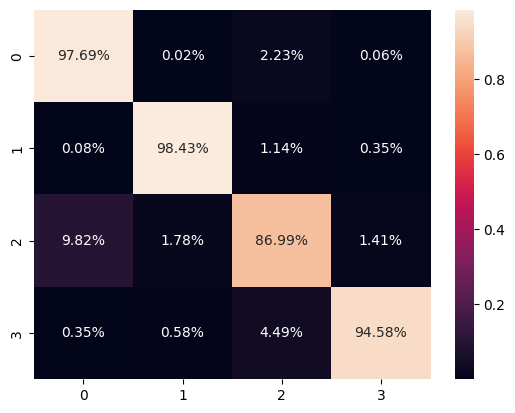

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.RandomForestClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/114408519.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train, y_train)


Test Accuracy :  97.44%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     85565
           1       0.98      1.00      0.99     19319
           2       0.93      0.90      0.91     18805
           3       0.99      0.94      0.96      6550

    accuracy                           0.97    130239
   macro avg       0.97      0.96      0.96    130239
weighted avg       0.97      0.97      0.97    130239

             Confusion_matrix 


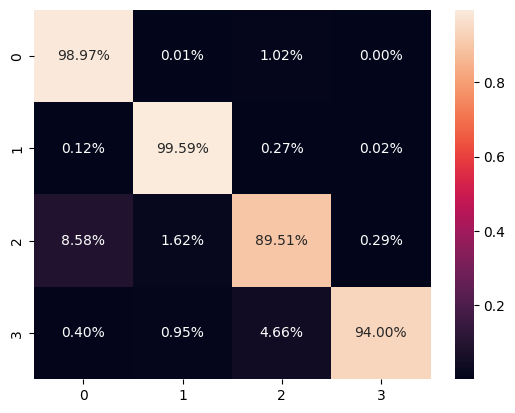

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  82.67%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.85      0.99      0.92     85565
           1       0.90      0.93      0.92     19319
           2       0.42      0.16      0.23     18805
           3       0.55      0.26      0.35      6550

    accuracy                           0.83    130239
   macro avg       0.68      0.59      0.60    130239
weighted avg       0.78      0.83      0.79    130239

             Confusion_matrix 


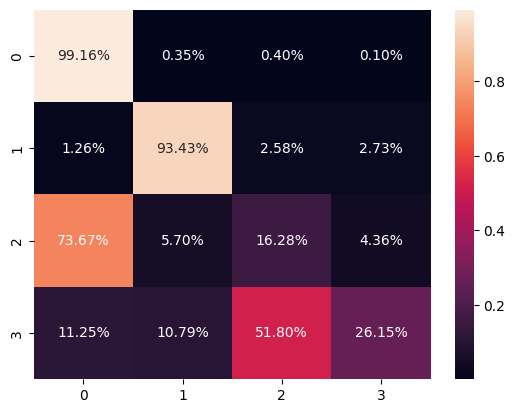

###################- End -###################
#############################################
######-Model => <class 'sklearn.neighbors._classification.KNeighborsClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Test Accuracy :  94.90%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     85565
           1       0.93      0.98      0.95     19319
           2       0.88      0.80      0.84     18805
           3       0.96      0.91      0.93      6550

    accuracy                           0.95    130239
   macro avg       0.93      0.92      0.92    130239
weighted avg       0.95      0.95      0.95    130239

             Confusion_matrix 


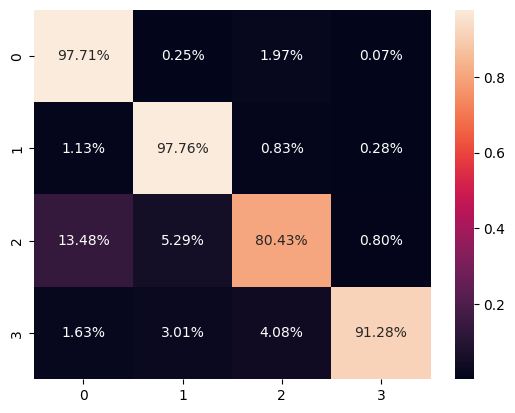

###################- End -###################
#############################################
######-Model => <class 'sklearn.linear_model._stochastic_gradient.SGDClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  82.31%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     85565
           1       0.83      0.79      0.81     19319
           2       0.48      0.26      0.34     18805
           3       0.76      0.67      0.71      6550

    accuracy                           0.82    130239
   macro avg       0.73      0.67      0.69    130239
weighted avg       0.80      0.82      0.80    130239

             Confusion_matrix 


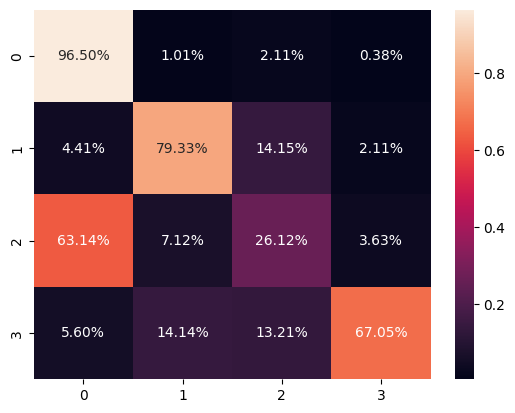

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.ExtraTreesClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/114408519.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train, y_train)


Test Accuracy :  97.34%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     85565
           1       0.98      1.00      0.99     19319
           2       0.93      0.89      0.91     18805
           3       0.99      0.94      0.97      6550

    accuracy                           0.97    130239
   macro avg       0.97      0.95      0.96    130239
weighted avg       0.97      0.97      0.97    130239

             Confusion_matrix 


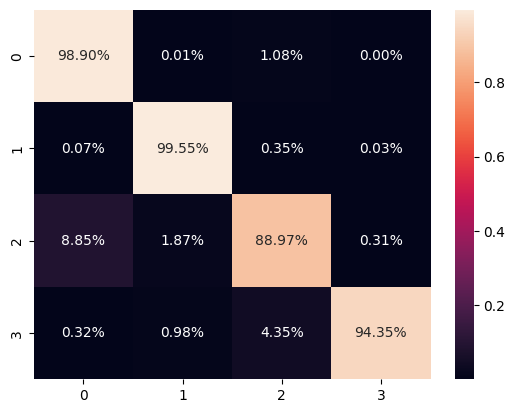

###################- End -###################
#############################################
######-Model => <class 'sklearn.naive_bayes.GaussianNB'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  79.19%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.84      0.91      0.88     85565
           1       0.69      0.98      0.81     19319
           2       0.54      0.07      0.12     18805
           3       0.62      0.74      0.68      6550

    accuracy                           0.79    130239
   macro avg       0.67      0.68      0.62    130239
weighted avg       0.76      0.79      0.75    130239

             Confusion_matrix 


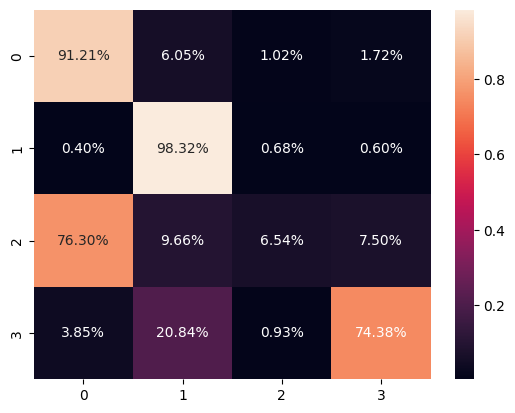

###################- End -###################


In [ ]:
models = [DecisionTreeClassifier,RandomForestClassifier,AdaBoostClassifier,KNeighborsClassifier,SGDClassifier,
         ExtraTreesClassifier,GaussianNB]
accuracy_test=[]
for m in models:
    print('#############################################')
    print('######-Model =>\033[07m {} \033[0m'.format(m))
    model_ = m()
    model_.fit(X_train, y_train)
    pred = model_.predict(X_test)
    acc = accuracy_score(pred, y_test)
    accuracy_test.append(acc)
    print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
    print('\033[01m              Classification_report \033[0m')
    print(classification_report(y_test, pred))
    print('\033[01m             Confusion_matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, pred)
    cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
    plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
    plt.show()
    print('\033[31m###################- End -###################\033[0m')

#############################################
######-Model => <class 'sklearn.tree._classes.DecisionTreeClassifier'> 
Test Accuracy :  86.80%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     85565
           1       0.82      0.81      0.82     19319
           2       0.70      0.62      0.65     18805
           3       0.58      0.76      0.66      6550

    accuracy                           0.87    130239
   macro avg       0.76      0.78      0.77    130239
weighted avg       0.87      0.87      0.87    130239

             Confusion_matrix 


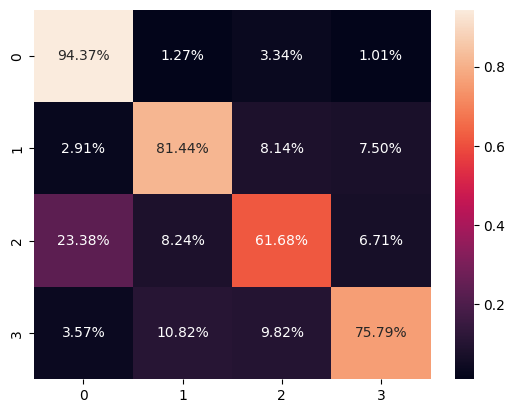

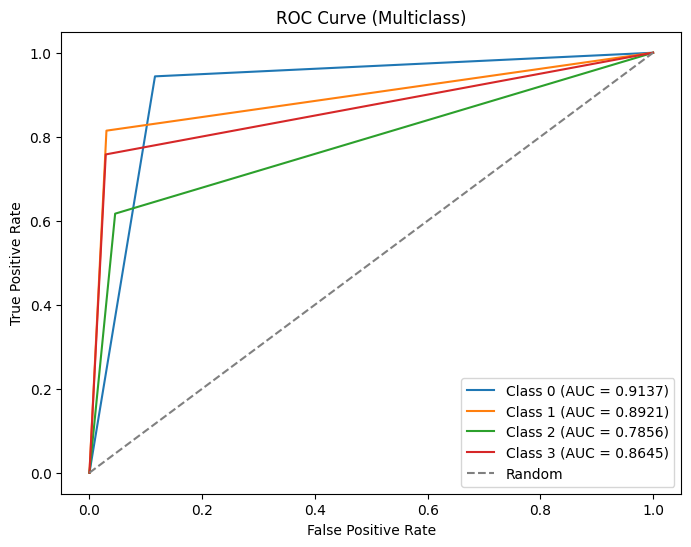

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.RandomForestClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/1050608441.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train[:1000], y_train[:1000])


Test Accuracy :  89.72%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     85565
           1       0.84      0.95      0.89     19319
           2       0.85      0.55      0.67     18805
           3       0.78      0.74      0.76      6550

    accuracy                           0.90    130239
   macro avg       0.85      0.80      0.82    130239
weighted avg       0.89      0.90      0.89    130239

             Confusion_matrix 


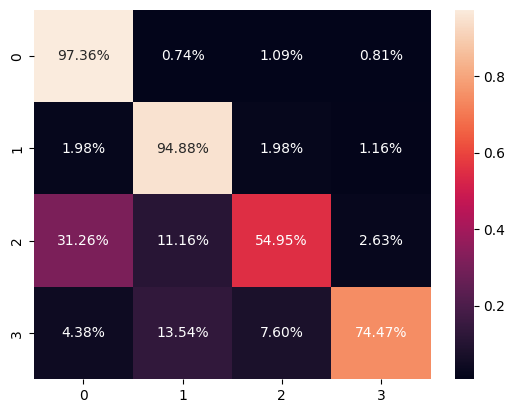

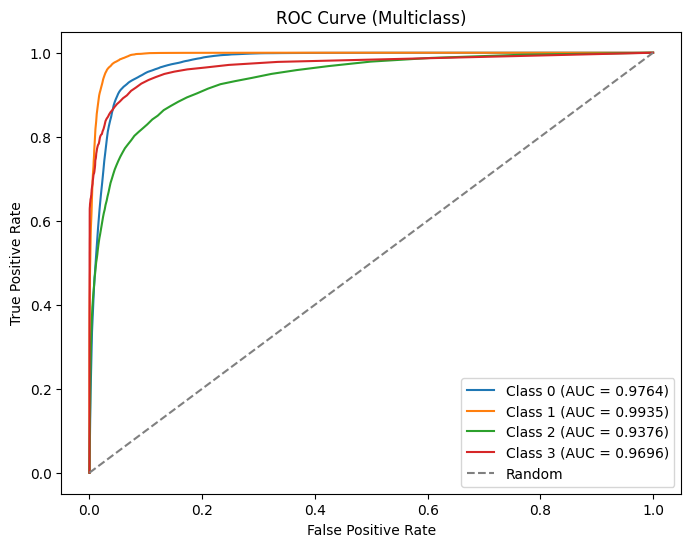

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  47.10%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.91      0.31      0.46     85565
           1       0.80      0.79      0.80     19319
           2       0.21      0.81      0.33     18805
           3       0.50      0.68      0.57      6550

    accuracy                           0.47    130239
   macro avg       0.60      0.65      0.54    130239
weighted avg       0.77      0.47      0.50    130239

             Confusion_matrix 


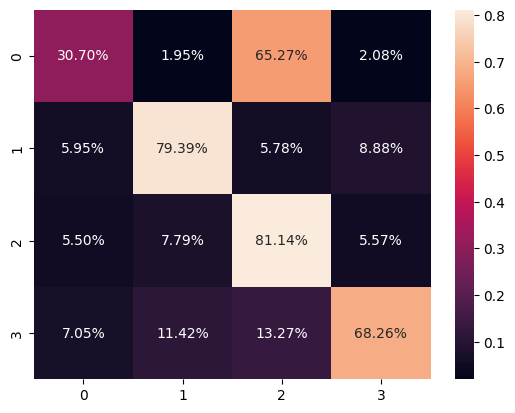

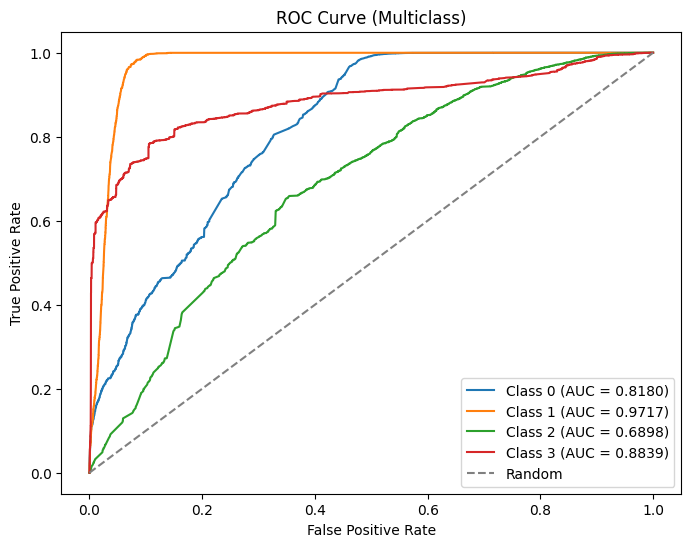

###################- End -###################
#############################################
######-Model => <class 'sklearn.neighbors._classification.KNeighborsClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Test Accuracy :  77.82%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.79      0.94      0.86     85565
           1       0.72      0.69      0.70     19319
           2       0.63      0.22      0.32     18805
           3       0.91      0.55      0.69      6550

    accuracy                           0.78    130239
   macro avg       0.76      0.60      0.64    130239
weighted avg       0.76      0.78      0.75    130239

             Confusion_matrix 


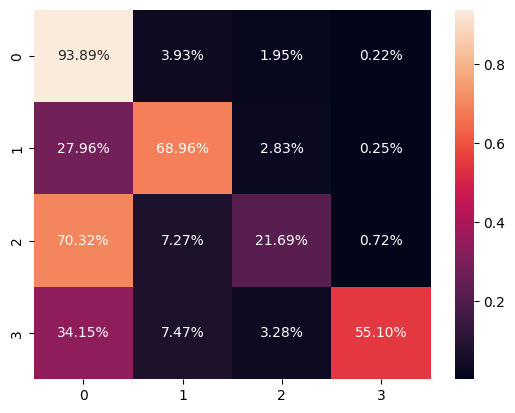

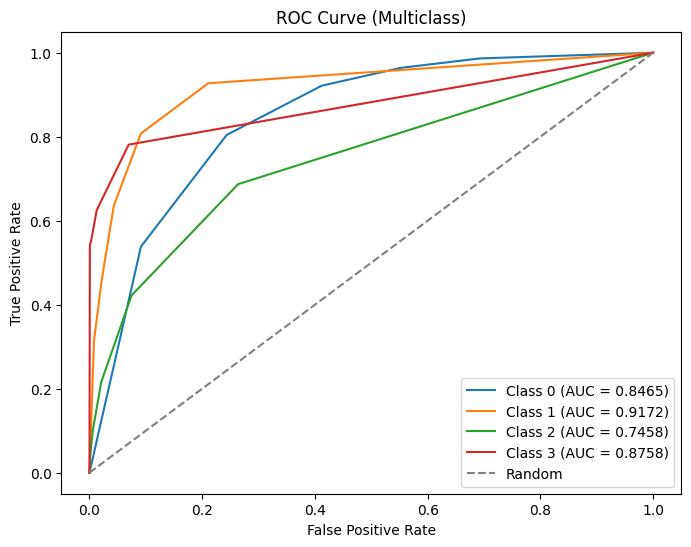

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.ExtraTreesClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/1050608441.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train[:1000], y_train[:1000])


Test Accuracy :  89.39%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     85565
           1       0.83      0.97      0.90     19319
           2       0.88      0.49      0.63     18805
           3       0.81      0.76      0.78      6550

    accuracy                           0.89    130239
   macro avg       0.86      0.80      0.81    130239
weighted avg       0.89      0.89      0.88    130239

             Confusion_matrix 


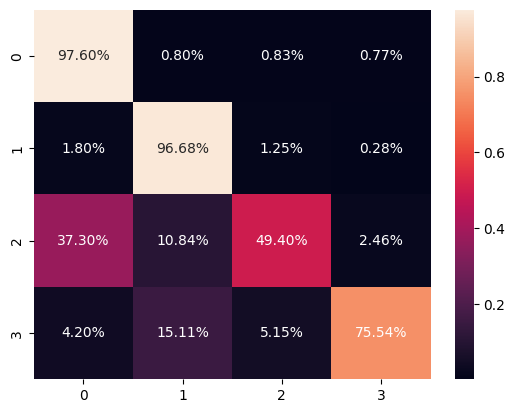

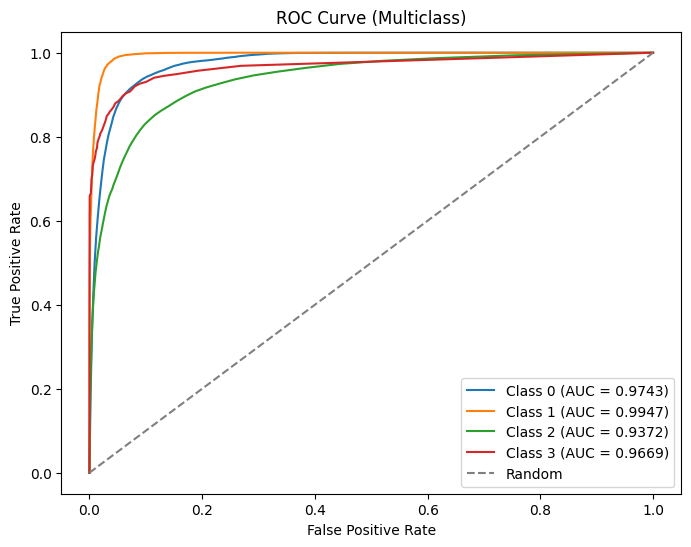

###################- End -###################
#############################################
######-Model => <class 'sklearn.naive_bayes.GaussianNB'> 
Test Accuracy :  61.52%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.95      0.50      0.66     85565
           1       0.70      0.97      0.82     19319
           2       0.28      0.78      0.41     18805
           3       0.69      0.58      0.63      6550

    accuracy                           0.62    130239
   macro avg       0.66      0.71      0.63    130239
weighted avg       0.81      0.62      0.64    130239

             Confusion_matrix 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


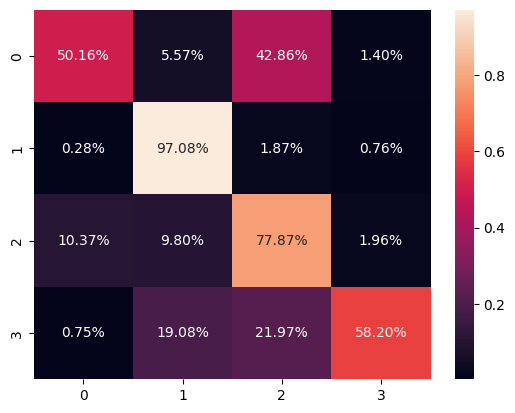

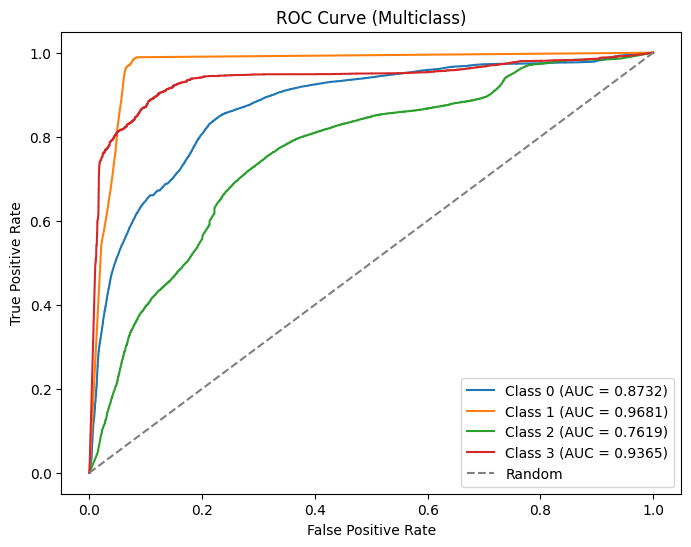

###################- End -###################


In [ ]:
models = [DecisionTreeClassifier,RandomForestClassifier,AdaBoostClassifier,KNeighborsClassifier,
         ExtraTreesClassifier,GaussianNB]
accuracy_test=[]
for m in models:
    print('#############################################')
    print('######-Model =>\033[07m {} \033[0m'.format(m))
    model_= m()
    model_.fit(X_train[:1000], y_train[:1000])
    pred = model_.predict(X_test)
    acc = accuracy_score(pred, y_test)
    accuracy_test.append(acc)
    print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
    print('\033[01m              Classification_report \033[0m')
    print(classification_report(y_test, pred))
    print('\033[01m             Confusion_matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, pred)
    cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
    plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
    plt.savefig('S-CF'+str(m)+'.jpg', dpi=300)
    plt.show()

    # ROC Curve and AUC for each class
    num_classes=4
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    y_proba=model_.predict_proba(X_test)
    y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC Curve for each class
    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

    plt.title('ROC Curve (Multiclass)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig('S-ROC'+str(m)+'.jpg', dpi=300)
    plt.show()
    print('\033[31m###################- End -###################\033[0m')



#############################################
SVC


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  72.84%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.72      0.98      0.83     85565
           1       0.80      0.40      0.53     19319
           2       0.80      0.01      0.01     18805
           3       0.96      0.47      0.63      6550

    accuracy                           0.73    130239
   macro avg       0.82      0.47      0.50    130239
weighted avg       0.75      0.73      0.66    130239

             Confusion_matrix 


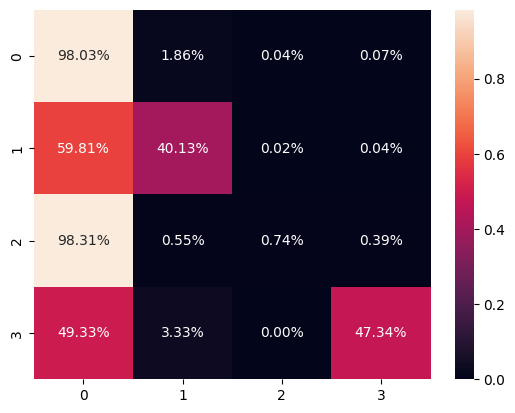

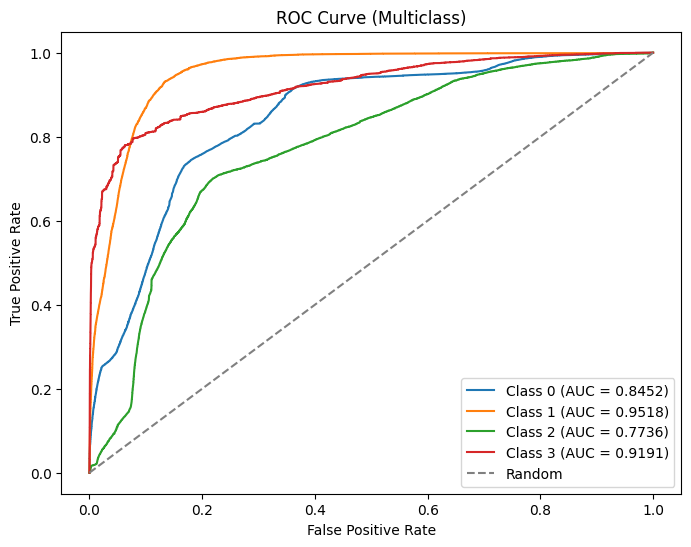

###################- End -###################


In [ ]:
print('#############################################')
print('SVC')
model_= SVC(probability=True)
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
print('\033[01m              Classification_report \033[0m')
print(classification_report(y_test, pred))
print('\033[01m             Confusion_matrix \033[0m')
cf_matrix = confusion_matrix(y_test, pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('S-CF-SVC.jpg', dpi=300)
plt.show()

# ROC Curve and AUC for each class
num_classes=4
fpr = dict()
tpr = dict()
roc_auc = dict()
y_proba=model_.predict_proba(X_test)
y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

for i in range(num_classes):
      fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
      roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
     plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('S-ROC-SVC.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')



#############################################
SGD
Test Accuracy :  74.49%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.79      0.98      0.87     85565
           1       0.95      0.32      0.48     19319
           2       0.25      0.12      0.16     18805
           3       0.58      0.73      0.64      6550

    accuracy                           0.74    130239
   macro avg       0.64      0.54      0.54    130239
weighted avg       0.72      0.74      0.70    130239

             Confusion_matrix 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


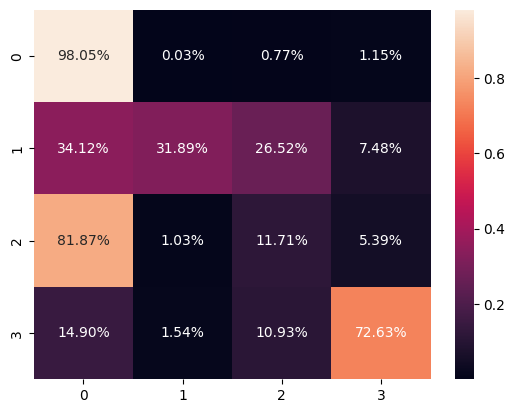

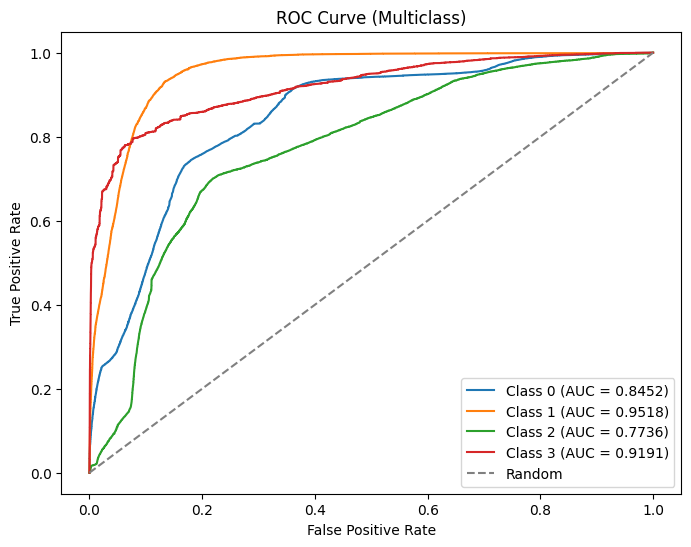

###################- End -###################


In [ ]:
print('#############################################')
print('SGD')
model_ = SGDClassifier(loss='log')
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
print('\033[01m              Classification_report \033[0m')
print(classification_report(y_test, pred))
print('\033[01m             Confusion_matrix \033[0m')
cf_matrix = confusion_matrix(y_test, pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('S-CF-SGD.jpg', dpi=300)
plt.show()

# ROC Curve and AUC for each class
num_classes = 4
fpr = dict()
tpr = dict()
roc_auc = dict()

# Remove NaN values from y_true_one_hot and y_proba
valid_indices = ~np.isnan(y_true_one_hot).any(axis=1) & ~np.isnan(y_proba).any(axis=1)
y_true_one_hot = y_true_one_hot[valid_indices]
y_proba = y_proba[valid_indices]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('S-ROC-SGD.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')


###selecting features by correlation

In [ ]:
correlation_matrix=df_final.corr()['Category']

/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/1673852107.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix=df_final.corr()['Category']


In [ ]:
threshold = 0.1  # Adjust this threshold to your preference

selected_features = correlation_matrix[abs(correlation_matrix) >= threshold].index.tolist()

In [ ]:
selected_features

['Category',
 '-',
 '.',
 '//',
 'https',
 'Abnormal_URL',
 'is_ip',
 'count_dir_in_url_path',
 'pc_alphas',
 'pc_digits',
 'pc_puncs',
 'has_port_no',
 'entropy_of_domain',
 'entropy_of_tld',
 'entropy_of_fld']

In [ ]:
df_high_corr= df_final[selected_features]

In [ ]:
df_high_corr.head()

,Category,-,.,//,https,Abnormal_URL,is_ip,count_dir_in_url_path,pc_alphas,pc_digits,pc_puncs,has_port_no,entropy_of_domain,entropy_of_tld,entropy_of_fld
0,2,1,2,0,0,0,0,0,0.812500,0.000000,0.187500,0,3.169925,2.584963,3.375000
1,0,0,2,0,0,0,0,2,0.828571,0.028571,0.142857,0,2.807355,1.584963,3.277613
2,0,0,2,0,0,0,0,3,0.806452,0.032258,0.161290,0,2.921928,1.584963,3.235926
3,1,1,3,1,0,1,0,1,0.715909,0.079545,0.204545,0,2.896292,1.000000,3.146286
4,1,1,2,1,0,1,0,1,0.846809,0.093617,0.059574,0,3.405822,1.584963,3.501398


In [ ]:
X=df_high_corr.drop(['Category'], axis=1)

In [ ]:
y=df_high_corr[['Category']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#############################################
######-Model => <class 'sklearn.tree._classes.DecisionTreeClassifier'> 
Test Accuracy :  82.53%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     85565
           1       0.85      0.82      0.84     19319
           2       0.53      0.48      0.50     18805
           3       0.60      0.76      0.67      6550

    accuracy                           0.83    130239
   macro avg       0.72      0.74      0.73    130239
weighted avg       0.82      0.83      0.82    130239

             Confusion_matrix 


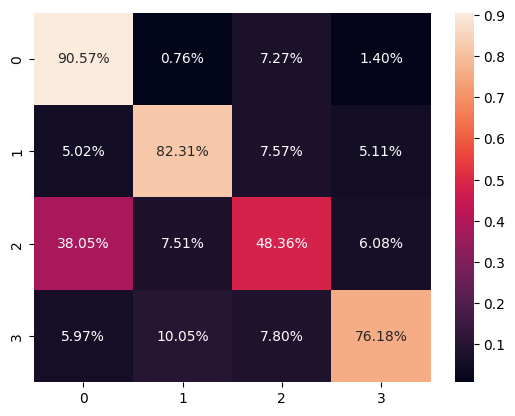

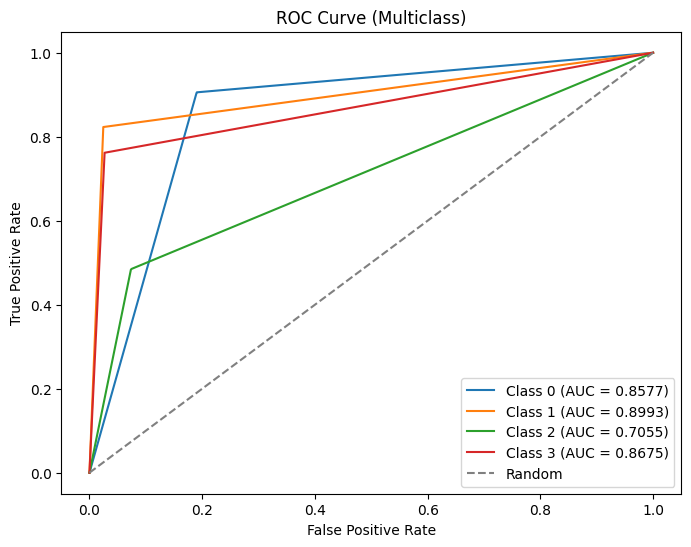

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.RandomForestClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/3539332130.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train[:1000], y_train[:1000])


Test Accuracy :  86.80%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     85565
           1       0.80      0.94      0.87     19319
           2       0.88      0.36      0.51     18805
           3       0.73      0.74      0.74      6550

    accuracy                           0.87    130239
   macro avg       0.83      0.76      0.76    130239
weighted avg       0.87      0.87      0.85    130239

             Confusion_matrix 


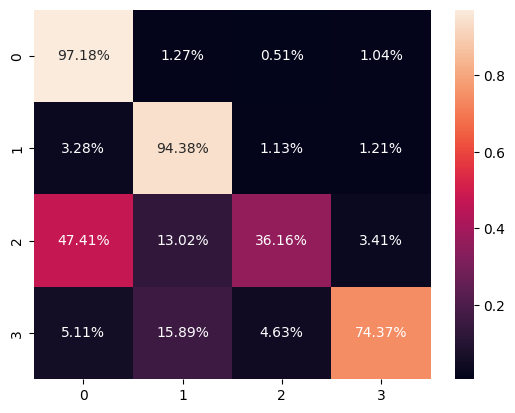

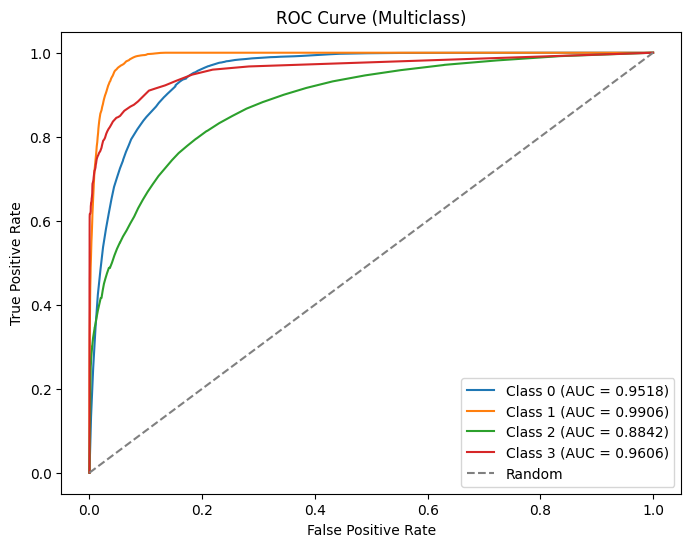

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  64.86%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.86      0.65      0.74     85565
           1       0.78      0.87      0.82     19319
           2       0.22      0.43      0.29     18805
           3       0.57      0.64      0.60      6550

    accuracy                           0.65    130239
   macro avg       0.61      0.65      0.61    130239
weighted avg       0.74      0.65      0.68    130239

             Confusion_matrix 


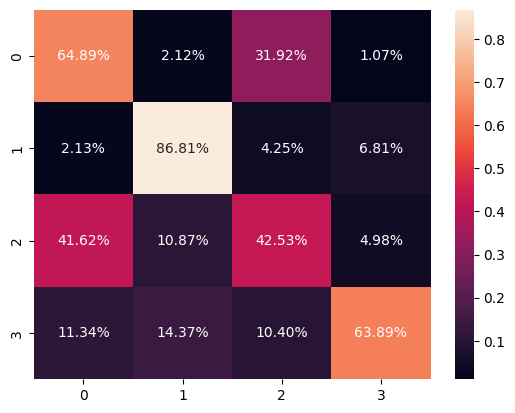

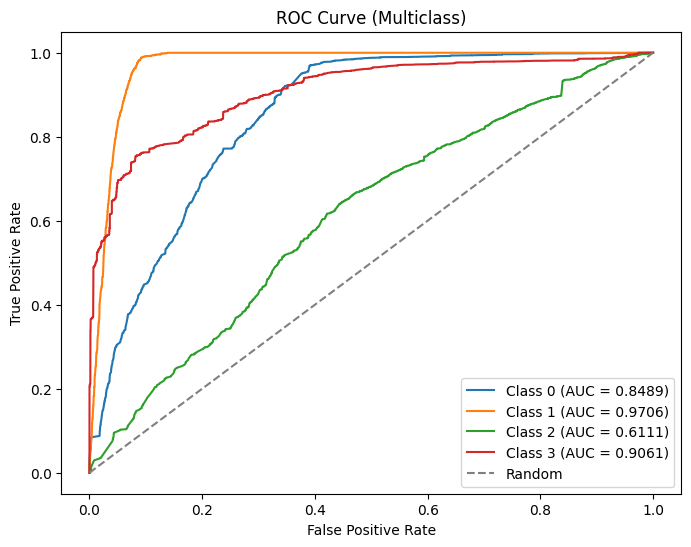

###################- End -###################
#############################################
######-Model => <class 'sklearn.neighbors._classification.KNeighborsClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Test Accuracy :  84.09%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     85565
           1       0.80      0.88      0.84     19319
           2       0.68      0.30      0.42     18805
           3       0.81      0.68      0.74      6550

    accuracy                           0.84    130239
   macro avg       0.79      0.71      0.73    130239
weighted avg       0.83      0.84      0.82    130239

             Confusion_matrix 


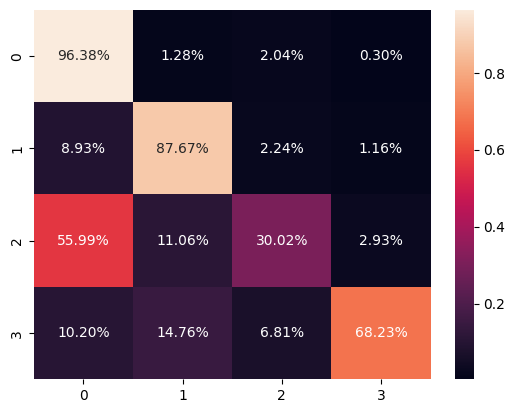

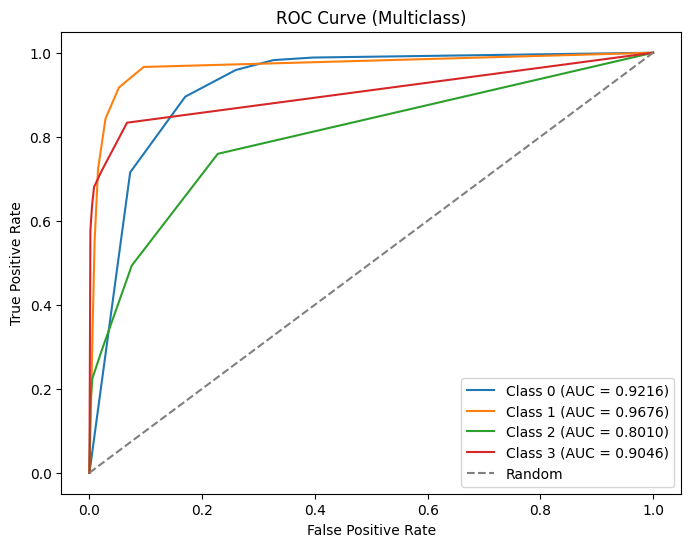

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.ExtraTreesClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/3539332130.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train[:1000], y_train[:1000])


Test Accuracy :  86.59%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     85565
           1       0.81      0.96      0.88     19319
           2       0.84      0.34      0.49     18805
           3       0.75      0.75      0.75      6550

    accuracy                           0.87    130239
   macro avg       0.82      0.75      0.76    130239
weighted avg       0.86      0.87      0.85    130239

             Confusion_matrix 


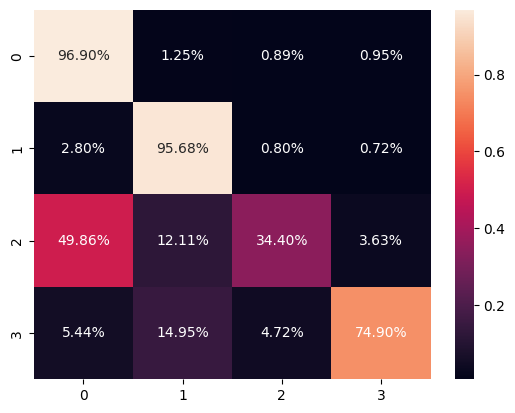

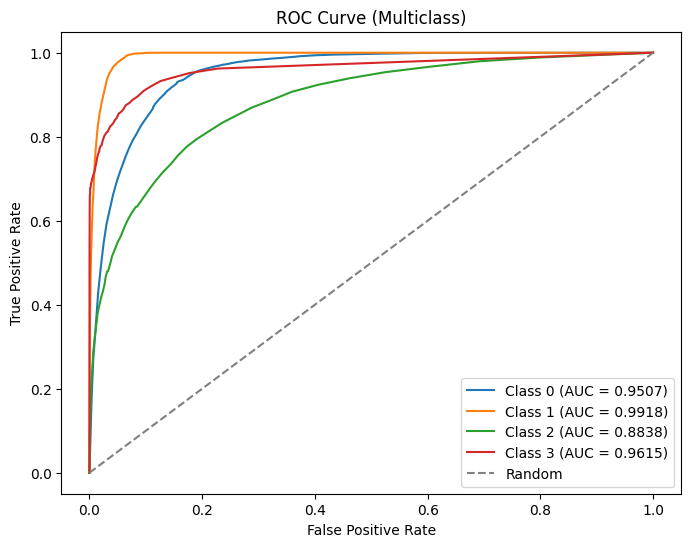

###################- End -###################
#############################################
######-Model => <class 'sklearn.naive_bayes.GaussianNB'> 
Test Accuracy :  77.79%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.85      0.90      0.87     85565
           1       0.65      1.00      0.78     19319
           2       0.32      0.10      0.16     18805
           3       0.88      0.49      0.63      6550

    accuracy                           0.78    130239
   macro avg       0.68      0.62      0.61    130239
weighted avg       0.74      0.78      0.74    130239

             Confusion_matrix 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


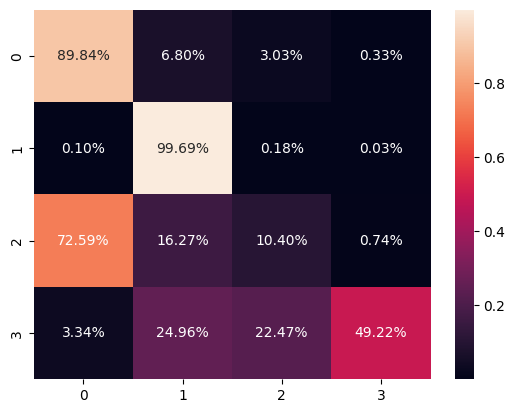

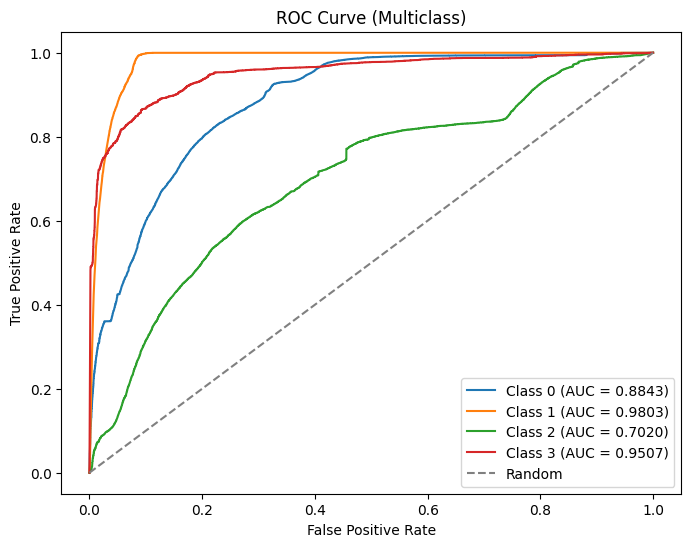

###################- End -###################


In [ ]:
models = [DecisionTreeClassifier,RandomForestClassifier,AdaBoostClassifier,KNeighborsClassifier,
         ExtraTreesClassifier,GaussianNB]
accuracy_test=[]
for m in models:
    print('#############################################')
    print('######-Model =>\033[07m {} \033[0m'.format(m))
    model_= m()
    model_.fit(X_train[:1000], y_train[:1000])
    pred = model_.predict(X_test)
    acc = accuracy_score(pred, y_test)
    accuracy_test.append(acc)
    print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
    print('\033[01m              Classification_report \033[0m')
    print(classification_report(y_test, pred))
    print('\033[01m             Confusion_matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, pred)
    cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
    plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
    plt.savefig('C-CF'+str(m)+'.jpg', dpi=300)
    plt.show()

    # ROC Curve and AUC for each class
    num_classes=4
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    y_proba=model_.predict_proba(X_test)
    y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC Curve for each class
    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

    plt.title('ROC Curve (Multiclass)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig('C-ROC'+str(m)+'.jpg', dpi=300)
    plt.show()
    print('\033[31m###################- End -###################\033[0m')



#############################################
SVC


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  81.72%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     85565
           1       0.74      0.94      0.83     19319
           2       0.60      0.02      0.04     18805
           3       0.82      0.68      0.75      6550

    accuracy                           0.82    130239
   macro avg       0.75      0.66      0.63    130239
weighted avg       0.79      0.82      0.76    130239

             Confusion_matrix 


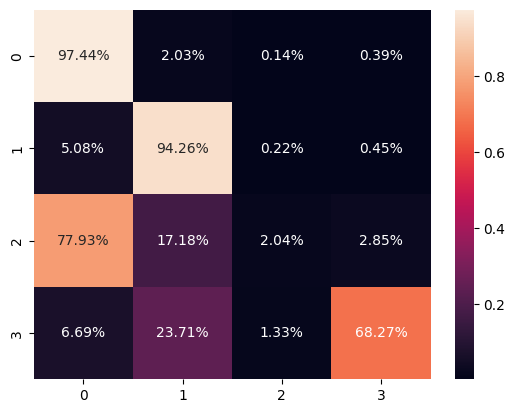

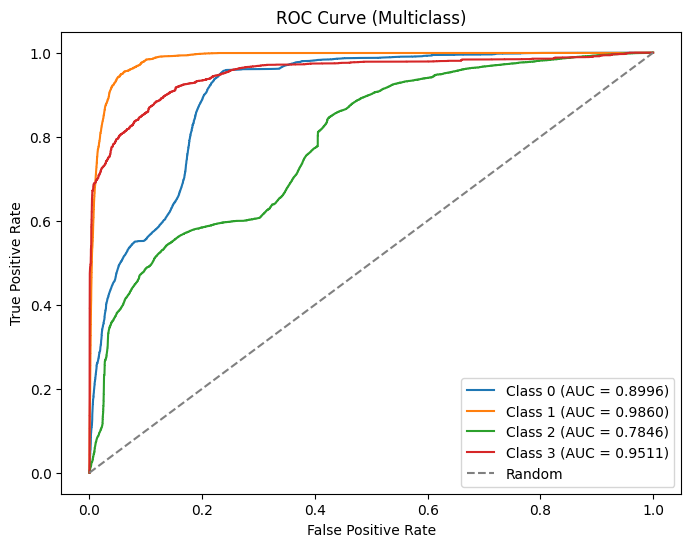

###################- End -###################


In [ ]:
print('#############################################')
print('SVC')
model_= SVC(probability=True)
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
print('\033[01m              Classification_report \033[0m')
print(classification_report(y_test, pred))
print('\033[01m             Confusion_matrix \033[0m')
cf_matrix = confusion_matrix(y_test, pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('C-CF-SVC.jpg', dpi=300)
plt.show()

# ROC Curve and AUC for each class
num_classes=4
fpr = dict()
tpr = dict()
roc_auc = dict()
y_proba=model_.predict_proba(X_test)
y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

for i in range(num_classes):
      fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
      roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
     plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('C-ROC-SVC.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')



#############################################
SGD
Test Accuracy :  75.15%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.81      0.97      0.88     85565
           1       0.83      0.47      0.60     19319
           2       0.19      0.12      0.15     18805
           3       0.69      0.54      0.61      6550

    accuracy                           0.75    130239
   macro avg       0.63      0.53      0.56    130239
weighted avg       0.72      0.75      0.72    130239

             Confusion_matrix 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


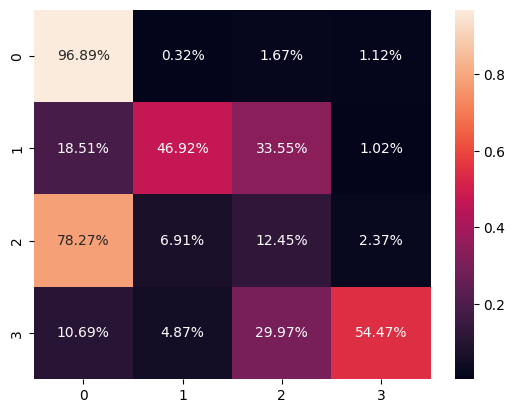

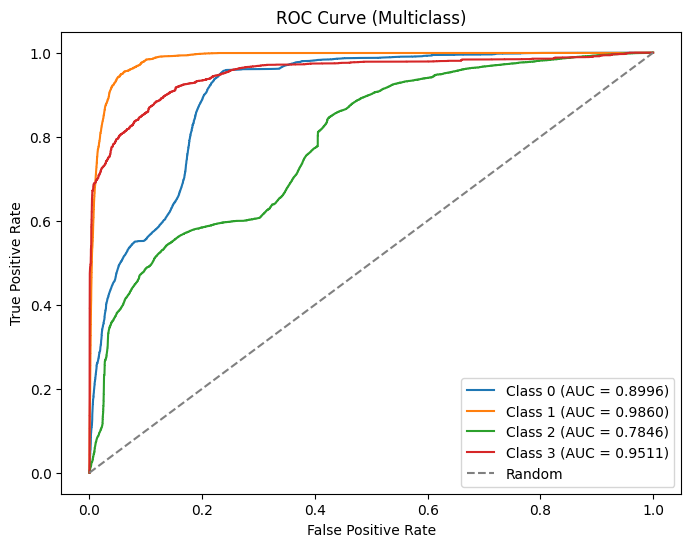

###################- End -###################


In [ ]:
print('#############################################')
print('SGD')
model_ = SGDClassifier(loss='log')
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
print('\033[01m              Classification_report \033[0m')
print(classification_report(y_test, pred))
print('\033[01m             Confusion_matrix \033[0m')
cf_matrix = confusion_matrix(y_test, pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('C-CF-SGD.jpg', dpi=300)
plt.show()

# ROC Curve and AUC for each class
num_classes = 4
fpr = dict()
tpr = dict()
roc_auc = dict()

# Remove NaN values from y_true_one_hot and y_proba
valid_indices = ~np.isnan(y_true_one_hot).any(axis=1) & ~np.isnan(y_proba).any(axis=1)
y_true_one_hot = y_true_one_hot[valid_indices]
y_proba = y_proba[valid_indices]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('C-ROC-SGD.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')



In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

Feature_importances = rf.feature_importances_
features = X.columns
sorted_indices = np.argsort(Feature_importances)

threshold = 0.01

selected_features_rf=[]
eliminated_features_rf=[]

for feature, importance in zip(features,Feature_importances):
    if importance>threshold:
        selected_features_rf.append(feature)
    else:
        eliminated_features_rf.append(feature)

/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/2697510839.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X, y)


In [ ]:
X=X[selected_features_rf]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#############################################
######-Model => <class 'sklearn.tree._classes.DecisionTreeClassifier'> 
Test Accuracy :  93.25%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     85565
           1       0.96      0.97      0.97     19319
           2       0.78      0.77      0.77     18805
           3       0.94      0.94      0.94      6550

    accuracy                           0.93    130239
   macro avg       0.91      0.91      0.91    130239
weighted avg       0.93      0.93      0.93    130239

             Confusion_matrix 


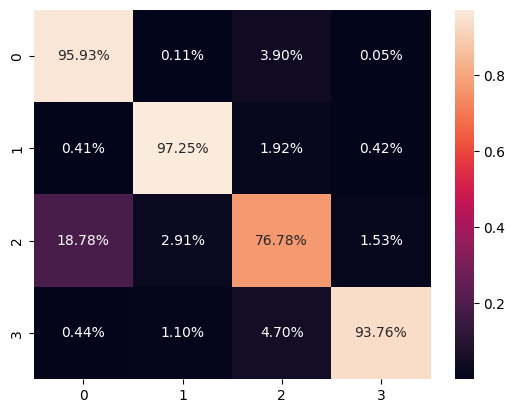

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.RandomForestClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/114408519.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train, y_train)


Test Accuracy :  94.87%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85565
           1       0.96      0.99      0.98     19319
           2       0.86      0.78      0.82     18805
           3       0.99      0.94      0.96      6550

    accuracy                           0.95    130239
   macro avg       0.94      0.92      0.93    130239
weighted avg       0.95      0.95      0.95    130239

             Confusion_matrix 


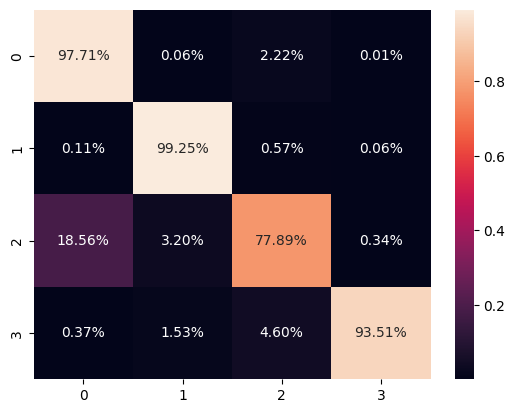

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  83.24%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.88      0.95      0.92     85565
           1       0.83      0.94      0.88     19319
           2       0.52      0.36      0.43     18805
           3       0.67      0.30      0.42      6550

    accuracy                           0.83    130239
   macro avg       0.73      0.64      0.66    130239
weighted avg       0.81      0.83      0.82    130239

             Confusion_matrix 


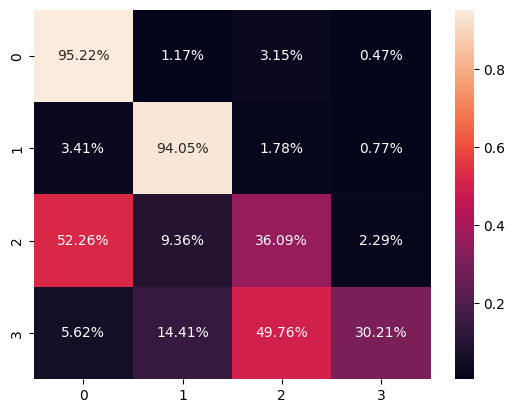

###################- End -###################
#############################################
######-Model => <class 'sklearn.neighbors._classification.KNeighborsClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Test Accuracy :  93.65%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     85565
           1       0.94      0.98      0.96     19319
           2       0.83      0.75      0.79     18805
           3       0.96      0.91      0.93      6550

    accuracy                           0.94    130239
   macro avg       0.92      0.90      0.91    130239
weighted avg       0.93      0.94      0.94    130239

             Confusion_matrix 


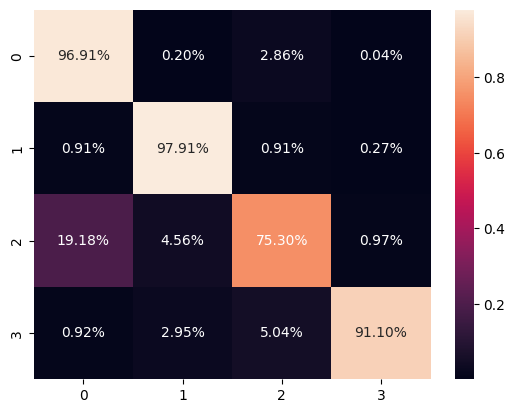

###################- End -###################
#############################################
######-Model => <class 'sklearn.linear_model._stochastic_gradient.SGDClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  81.49%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     85565
           1       0.75      0.95      0.84     19319
           2       0.65      0.02      0.04     18805
           3       0.65      0.76      0.70      6550

    accuracy                           0.81    130239
   macro avg       0.73      0.67      0.62    130239
weighted avg       0.79      0.81      0.76    130239

             Confusion_matrix 


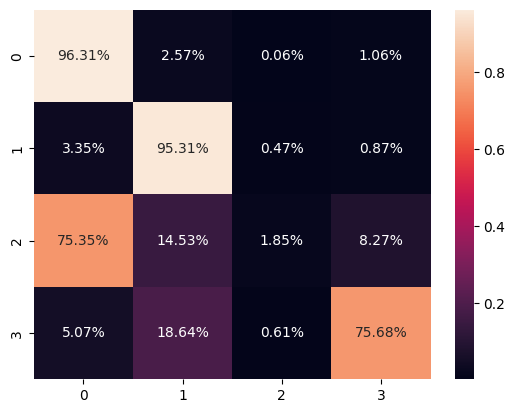

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.ExtraTreesClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/114408519.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train, y_train)


Test Accuracy :  94.81%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85565
           1       0.96      0.99      0.98     19319
           2       0.87      0.77      0.82     18805
           3       0.99      0.94      0.96      6550

    accuracy                           0.95    130239
   macro avg       0.94      0.92      0.93    130239
weighted avg       0.95      0.95      0.95    130239

             Confusion_matrix 


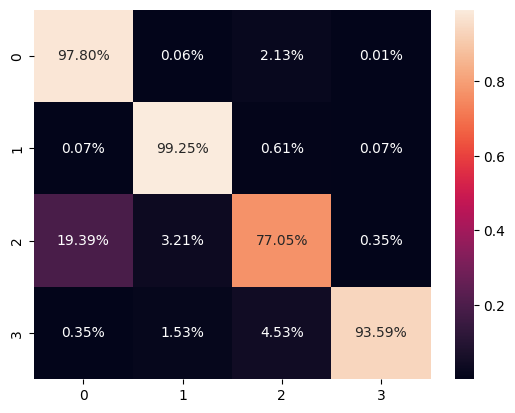

###################- End -###################
#############################################
######-Model => <class 'sklearn.naive_bayes.GaussianNB'> 
Test Accuracy :  78.26%  
              Classification_report 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       0.85      0.91      0.88     85565
           1       0.64      1.00      0.78     19319
           2       0.37      0.06      0.10     18805
           3       0.73      0.62      0.67      6550

    accuracy                           0.78    130239
   macro avg       0.65      0.65      0.61    130239
weighted avg       0.74      0.78      0.74    130239

             Confusion_matrix 


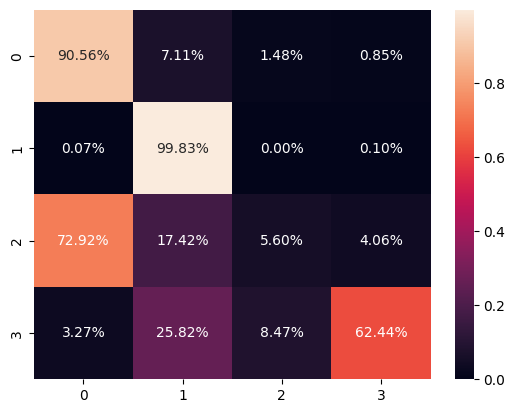

###################- End -###################


In [ ]:
models = [DecisionTreeClassifier,RandomForestClassifier,AdaBoostClassifier,KNeighborsClassifier,SGDClassifier,
         ExtraTreesClassifier,GaussianNB]
accuracy_test=[]
for m in models:
    print('#############################################')
    print('######-Model =>\033[07m {} \033[0m'.format(m))
    model_ = m()
    model_.fit(X_train, y_train)
    pred = model_.predict(X_test)
    acc = accuracy_score(pred, y_test)
    accuracy_test.append(acc)
    print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
    print('\033[01m              Classification_report \033[0m')
    print(classification_report(y_test, pred))
    print('\033[01m             Confusion_matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, pred)
    cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
    plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
    plt.show()
    print('\033[31m###################- End -###################\033[0m')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

#############################################
######-Model => <class 'sklearn.tree._classes.DecisionTreeClassifier'> 
Test Accuracy :  82.14%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     85565
           1       0.85      0.81      0.83     19319
           2       0.51      0.49      0.50     18805
           3       0.63      0.76      0.69      6550

    accuracy                           0.82    130239
   macro avg       0.72      0.74      0.73    130239
weighted avg       0.82      0.82      0.82    130239

             Confusion_matrix 


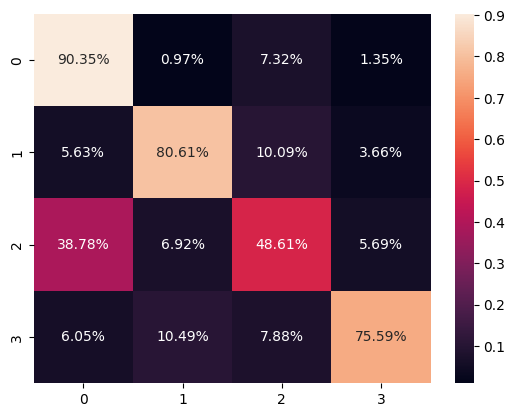

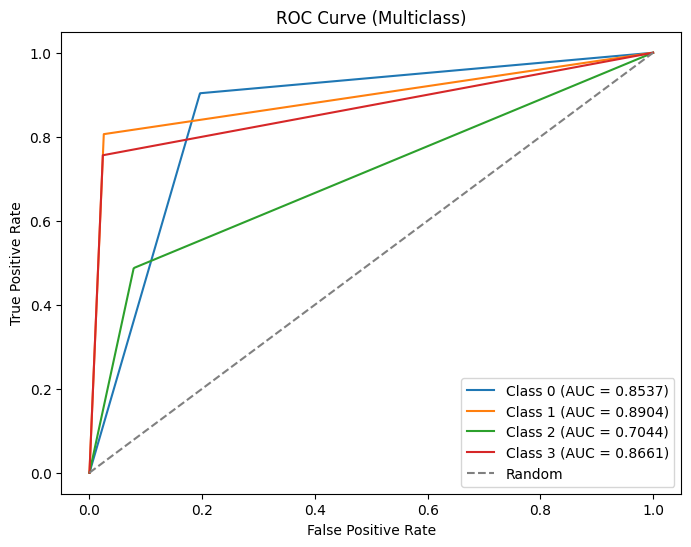

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.RandomForestClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/2795197376.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train[:1000], y_train[:1000])


Test Accuracy :  86.76%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     85565
           1       0.80      0.95      0.87     19319
           2       0.88      0.36      0.51     18805
           3       0.72      0.75      0.73      6550

    accuracy                           0.87    130239
   macro avg       0.82      0.76      0.76    130239
weighted avg       0.87      0.87      0.85    130239

             Confusion_matrix 


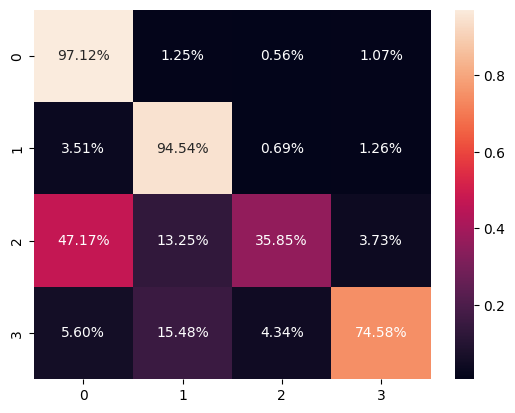

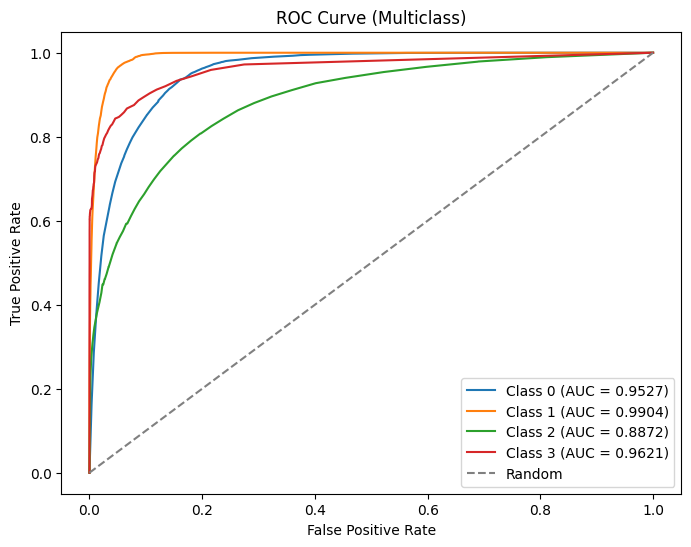

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  64.86%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.86      0.65      0.74     85565
           1       0.78      0.87      0.82     19319
           2       0.22      0.43      0.29     18805
           3       0.57      0.64      0.60      6550

    accuracy                           0.65    130239
   macro avg       0.61      0.65      0.61    130239
weighted avg       0.74      0.65      0.68    130239

             Confusion_matrix 


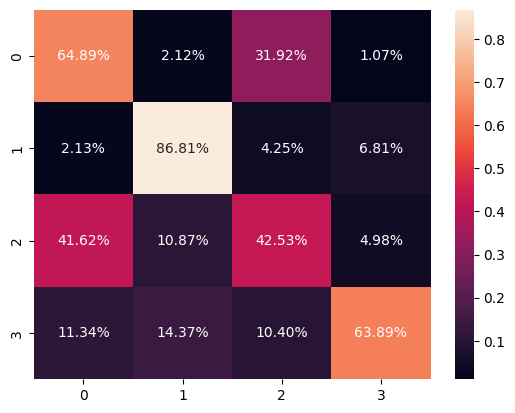

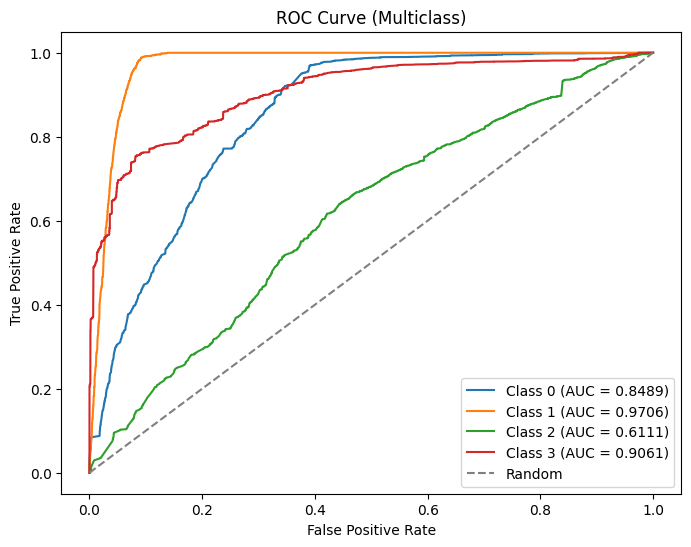

###################- End -###################
#############################################
######-Model => <class 'sklearn.neighbors._classification.KNeighborsClassifier'> 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Test Accuracy :  84.10%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     85565
           1       0.80      0.88      0.84     19319
           2       0.68      0.30      0.42     18805
           3       0.81      0.68      0.74      6550

    accuracy                           0.84    130239
   macro avg       0.79      0.71      0.73    130239
weighted avg       0.83      0.84      0.82    130239

             Confusion_matrix 


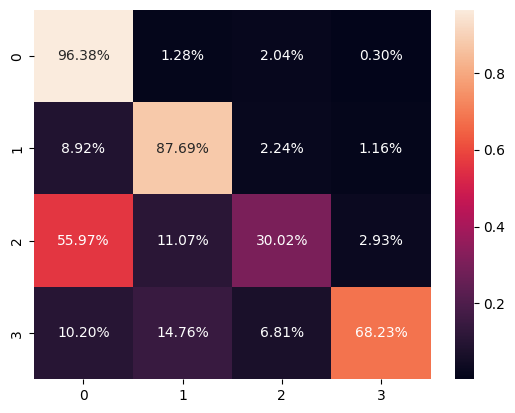

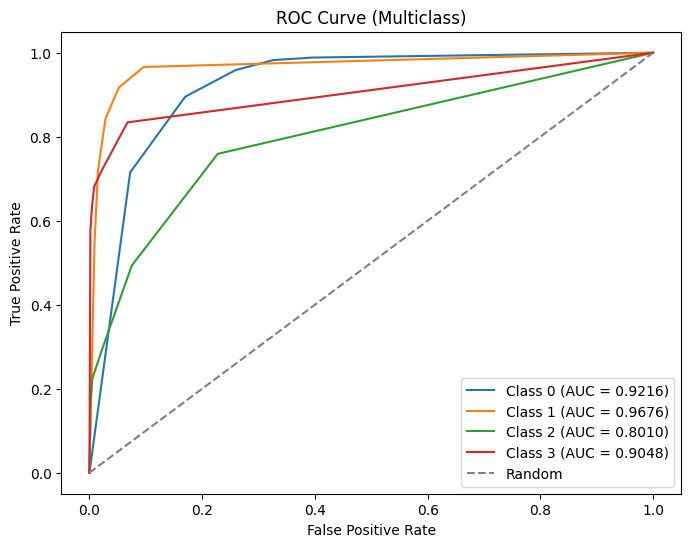

###################- End -###################
#############################################
######-Model => <class 'sklearn.ensemble._forest.ExtraTreesClassifier'> 


/var/folders/bp/1gmt4p8x50jd23mx_jqzgw5c0000gn/T/ipykernel_27428/2795197376.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model_.fit(X_train[:1000], y_train[:1000])


Test Accuracy :  86.80%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     85565
           1       0.82      0.95      0.88     19319
           2       0.85      0.36      0.50     18805
           3       0.73      0.75      0.74      6550

    accuracy                           0.87    130239
   macro avg       0.82      0.76      0.76    130239
weighted avg       0.87      0.87      0.85    130239

             Confusion_matrix 


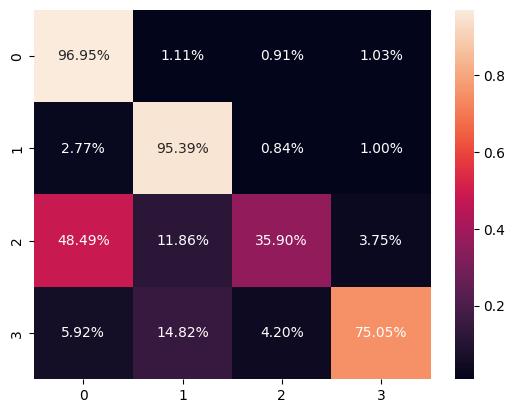

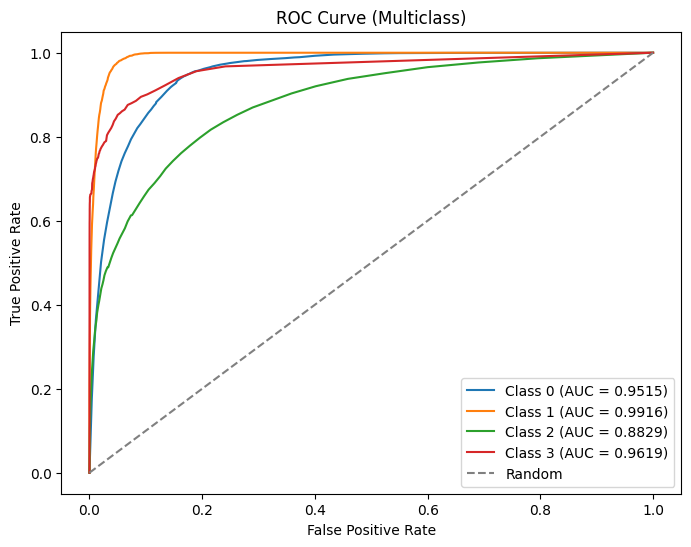

###################- End -###################
#############################################
######-Model => <class 'sklearn.naive_bayes.GaussianNB'> 
Test Accuracy :  77.98%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.85      0.90      0.87     85565
           1       0.65      1.00      0.79     19319
           2       0.34      0.09      0.15     18805
           3       0.80      0.56      0.66      6550

    accuracy                           0.78    130239
   macro avg       0.66      0.64      0.62    130239
weighted avg       0.74      0.78      0.74    130239

             Confusion_matrix 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


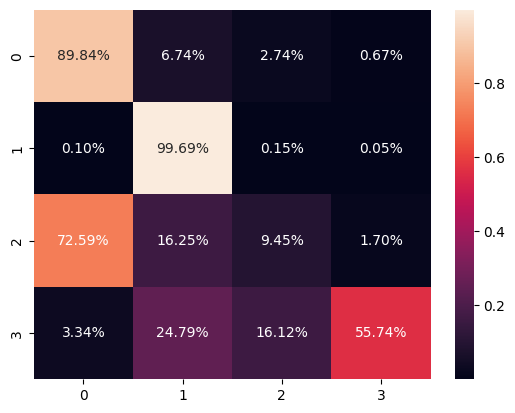

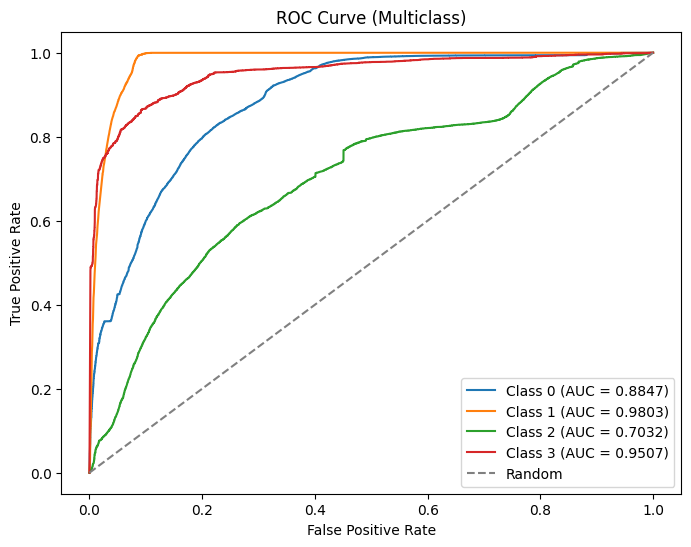

###################- End -###################


In [ ]:
models = [DecisionTreeClassifier,RandomForestClassifier,AdaBoostClassifier,KNeighborsClassifier,
         ExtraTreesClassifier,GaussianNB]
accuracy_test=[]
for m in models:
    print('#############################################')
    print('######-Model =>\033[07m {} \033[0m'.format(m))
    model_= m()
    model_.fit(X_train[:1000], y_train[:1000])
    pred = model_.predict(X_test)
    acc = accuracy_score(pred, y_test)
    accuracy_test.append(acc)
    print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
    print('\033[01m              Classification_report \033[0m')
    print(classification_report(y_test, pred))
    print('\033[01m             Confusion_matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, pred)
    cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
    plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
    plt.savefig('R-CF'+str(m)+'.jpg', dpi=300)
    plt.show()

    # ROC Curve and AUC for each class
    num_classes=4
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    y_proba=model_.predict_proba(X_test)
    y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC Curve for each class
    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

    plt.title('ROC Curve (Multiclass)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.savefig('R-ROC'+str(m)+'.jpg', dpi=300)
    plt.show()
    print('\033[31m###################- End -###################\033[0m')



#############################################
SVC


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Accuracy :  81.76%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     85565
           1       0.74      0.94      0.83     19319
           2       0.62      0.02      0.05     18805
           3       0.82      0.68      0.75      6550

    accuracy                           0.82    130239
   macro avg       0.75      0.66      0.63    130239
weighted avg       0.79      0.82      0.76    130239

             Confusion_matrix 


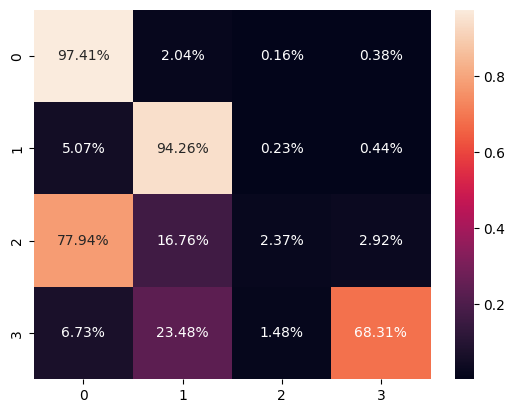

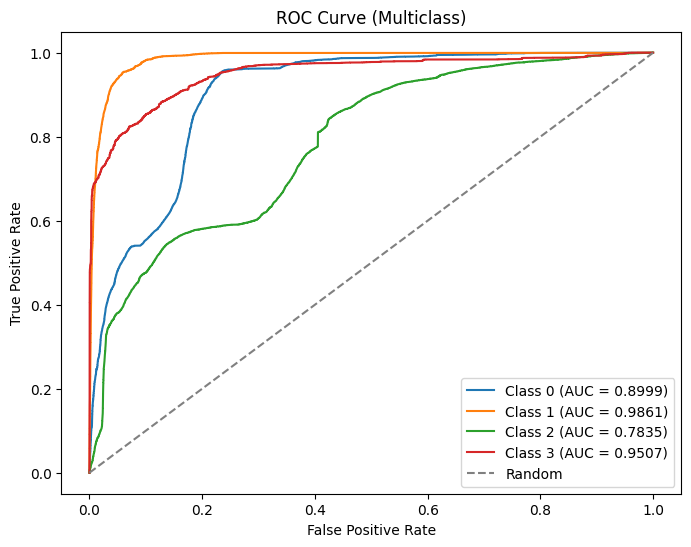

###################- End -###################


In [ ]:
print('#############################################')
print('SVC')
model_= SVC(probability=True)
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
print('\033[01m              Classification_report \033[0m')
print(classification_report(y_test, pred))
print('\033[01m             Confusion_matrix \033[0m')
cf_matrix = confusion_matrix(y_test, pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('R-CF-SVC.jpg', dpi=300)
plt.show()

# ROC Curve and AUC for each class
num_classes=4
fpr = dict()
tpr = dict()
roc_auc = dict()
y_proba=model_.predict_proba(X_test)
y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

for i in range(num_classes):
      fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
      roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
     plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('R-ROC-SVC.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')



#############################################
SGD
Test Accuracy :  79.98%  
              Classification_report 
              precision    recall  f1-score   support

           0       0.85      0.95      0.89     85565
           1       0.78      0.81      0.80     19319
           2       0.38      0.15      0.21     18805
           3       0.65      0.71      0.68      6550

    accuracy                           0.80    130239
   macro avg       0.67      0.65      0.65    130239
weighted avg       0.76      0.80      0.77    130239

             Confusion_matrix 


/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/Users/hinjam/Documents/PJ/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


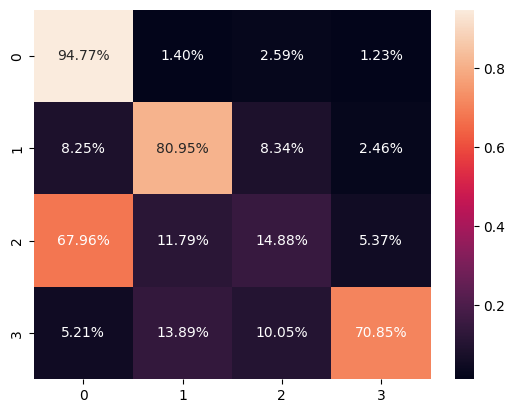

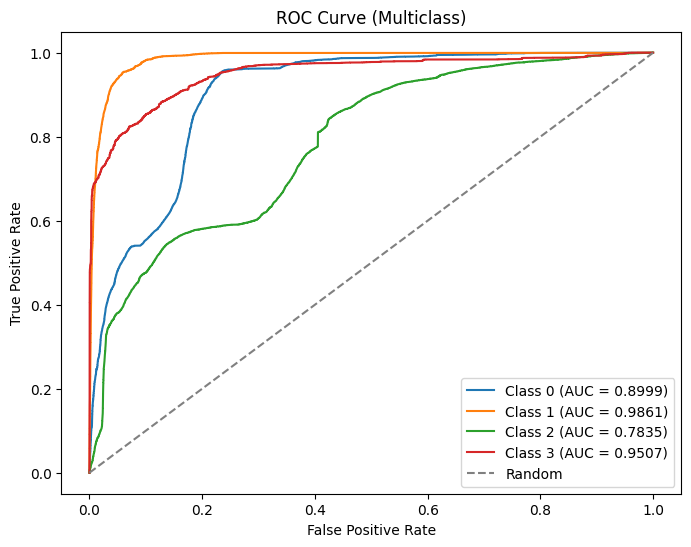

###################- End -###################


In [ ]:
print('#############################################')
print('SGD')
model_ = SGDClassifier(loss='log')
model_.fit(X_train[:1000], y_train[:1000])
pred = model_.predict(X_test)
acc = accuracy_score(pred, y_test)
accuracy_test.append(acc)
print('Test Accuracy :\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(acc*100))
print('\033[01m              Classification_report \033[0m')
print(classification_report(y_test, pred))
print('\033[01m             Confusion_matrix \033[0m')
cf_matrix = confusion_matrix(y_test, pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('R-CF-SGD.jpg', dpi=300)
plt.show()

# ROC Curve and AUC for each class
num_classes = 4
fpr = dict()
tpr = dict()
roc_auc = dict()

# Remove NaN values from y_true_one_hot and y_proba
valid_indices = ~np.isnan(y_true_one_hot).any(axis=1) & ~np.isnan(y_proba).any(axis=1)
y_true_one_hot = y_true_one_hot[valid_indices]
y_proba = y_proba[valid_indices]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('R-ROC-SGD.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')



#CNN

In [ ]:
X=df[['url']]
y=df[['Category']]

In [ ]:
y = pd.get_dummies(y, columns=['Category'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1000, shuffle=True)

In [ ]:
tokenizer = Tokenizer(filters='', char_level=True, lower=False, oov_token=1)

# Fit only on training data
tokenizer.fit_on_texts(X_train['url'])
n_char = len(tokenizer.word_index.keys())

train_seq = tokenizer.texts_to_sequences(X_train['url'])
val_seq = tokenizer.texts_to_sequences(X_test['url'])

print('Before tokenization: ')
print(X_train.iloc[0]['url'])
print('\nAfter tokenization: ')
print(train_seq[0])


Before tokenization: 
'ssl.allegro.pl.cgb5.com/\%20/fnd/authentication/enter_login.html'

After tokenization: 
[76, 10, 10, 14, 12, 5, 14, 14, 2, 21, 11, 3, 12, 15, 14, 12, 9, 21, 22, 33, 12, 9, 3, 13, 6, 75, 32, 25, 24, 6, 26, 8, 16, 6, 5, 20, 4, 18, 2, 8, 4, 7, 9, 5, 4, 7, 3, 8, 6, 2, 8, 4, 2, 11, 37, 14, 3, 21, 7, 8, 12, 18, 4, 13, 14, 76]


In [ ]:
sequence_length = np.array([len(i) for i in train_seq])
sequence_length = np.percentile(sequence_length, 99).astype(int)
print(f'Before padding: \n {train_seq[0]}')
train_seq = pad_sequences(train_seq, padding='post', maxlen=sequence_length)
val_seq = pad_sequences(val_seq, padding='post', maxlen=sequence_length)
print(f'After padding: \n {train_seq[0]}')

Before padding: 
 [76, 10, 10, 14, 12, 5, 14, 14, 2, 21, 11, 3, 12, 15, 14, 12, 9, 21, 22, 33, 12, 9, 3, 13, 6, 75, 32, 25, 24, 6, 26, 8, 16, 6, 5, 20, 4, 18, 2, 8, 4, 7, 9, 5, 4, 7, 3, 8, 6, 2, 8, 4, 2, 11, 37, 14, 3, 21, 7, 8, 12, 18, 4, 13, 14, 76]
After padding: 
 [76 10 10 14 12  5 14 14  2 21 11  3 12 15 14 12  9 21 22 33 12  9  3 13
  6 75 32 25 24  6 26  8 16  6  5 20  4 18  2  8  4  7  9  5  4  7  3  8
  6  2  8  4  2 11 37 14  3 21  7  8 12 18  4 13 14 76  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [ ]:
from tensorflow.keras import models

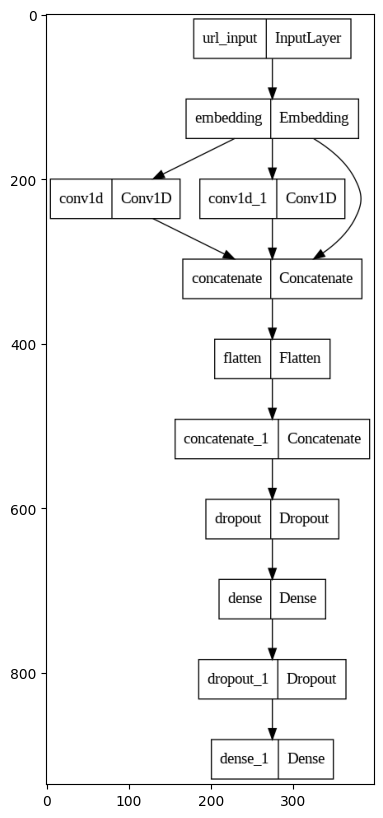

In [ ]:
def convolution_block(x):
    conv_3_layer = layers.Conv1D(64, 3, padding='same', activation='elu')(x)
    conv_5_layer = layers.Conv1D(64, 5, padding='same', activation='elu')(x)
    conv_layer = layers.concatenate([x, conv_3_layer, conv_5_layer])
    conv_layer = layers.Flatten()(conv_layer)
    return conv_layer


def create_model(sequence_length, n_char):
    input_layer = []

    # Sequence input layer
    sequence_input_layer = layers.Input(shape=(sequence_length,), name='url_input')
    input_layer.append(sequence_input_layer)

    # Convolution block
    char_embedding = layers.Embedding(n_char + 1, 32, input_length=sequence_length)(sequence_input_layer)
    conv_layer = convolution_block(char_embedding)

    # Concatenate all layers
    fc_layer = layers.concatenate([conv_layer])
    fc_layer = layers.Dropout(rate=0.5)(fc_layer)

    # Dense layer
    fc_layer = layers.Dense(128, activation='elu')(fc_layer)
    fc_layer = layers.Dropout(rate=0.2)(fc_layer)

    # Output layer for multiclass classification with 4 classes (use 'softmax' activation)
    output_layer = layers.Dense(4, activation='softmax')(fc_layer)
    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Reset session
backend.clear_session()
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(0)
random.seed(0)
tf.random.set_seed(0)

# Create model
model = create_model(sequence_length, n_char)

# Show model architecture
plot_model(model, to_file='model.png')
model_image = mpimg.imread('model.png')
plt.figure(figsize=(10, 10))
plt.imshow(model_image)
plt.savefig('CNN.jpg', dpi=300)
plt.show()


In [ ]:
# Create train data
train_x = [train_seq]


In [ ]:
# Model training
early_stopping = [EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max')]
history = model.fit(train_x, y_train, batch_size=64, epochs=25, verbose=1, validation_split=0.2, shuffle=True, callbacks=early_stopping)

model.save('model.h5')

Epoch 1/25
6512/6512 [==============================] - 80s 10ms/step - loss: 0.1933 - accuracy: 0.9357 - val_loss: 0.1234 - val_accuracy: 0.9607
Epoch 2/25
6512/6512 [==============================] - 62s 9ms/step - loss: 0.1302 - accuracy: 0.9585 - val_loss: 0.1084 - val_accuracy: 0.9650
Epoch 3/25
6512/6512 [==============================] - 54s 8ms/step - loss: 0.1142 - accuracy: 0.9632 - val_loss: 0.1082 - val_accuracy: 0.9666
Epoch 4/25
6512/6512 [==============================] - 54s 8ms/step - loss: 0.1039 - accuracy: 0.9666 - val_loss: 0.1022 - val_accuracy: 0.9688
Epoch 5/25
6512/6512 [==============================] - 55s 8ms/step - loss: 0.0976 - accuracy: 0.9685 - val_loss: 0.0995 - val_accuracy: 0.9702
Epoch 6/25
6512/6512 [==============================] - 51s 8ms/step - loss: 0.0920 - accuracy: 0.9702 - val_loss: 0.0962 - val_accuracy: 0.9712
Epoch 7/25
6512/6512 [==============================] - 60s 9ms/step - loss: 0.0882 - accuracy: 0.9715 - val_loss: 0.1027 - val_a

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
val_x = [val_seq]


val_pred = model.predict(val_x)
val_pred = np.argmax(val_pred, axis = 1)


4070/4070 [==============================] - 9s 2ms/step


In [ ]:
print(val_pred)

[0 0 2 ... 2 0 0]


In [ ]:
y_test= y_test.idxmax(axis=1)

In [ ]:
y_test = y_test.str.extract('(\d+)').astype(int)
y_test= y_test.values.ravel()

In [ ]:
print(f'\n\nClassification Report:\n{classification_report(y_test, val_pred)}')




Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     85615
           1       0.98      1.00      0.99     19440
           2       0.94      0.88      0.91     18764
           3       0.98      0.95      0.96      6420

    accuracy                           0.97    130239
   macro avg       0.97      0.95      0.96    130239
weighted avg       0.97      0.97      0.97    130239



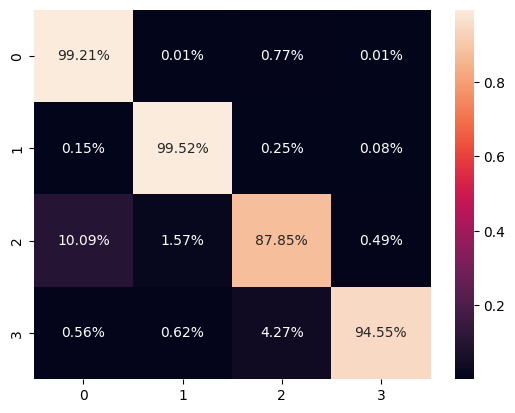

In [ ]:
cf_matrix = confusion_matrix(y_test, val_pred)
cf_matrix_normalized = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis]
plot_ = sns.heatmap(cf_matrix_normalized, annot=True, fmt='0.2%')
plt.savefig('CF-CNN.jpg', dpi=300)
plt.show()

4070/4070 [==============================] - 10s 2ms/step


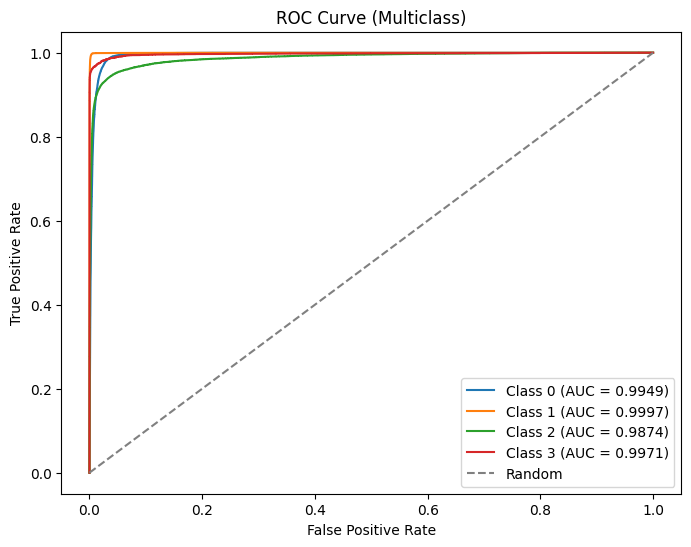

###################- End -###################


In [ ]:
# ROC Curve and AUC for each class
num_classes=4
fpr = dict()
tpr = dict()
roc_auc = dict()
y_proba=model.predict(val_x)
y_true_one_hot = label_binarize(y_test, classes=list(range(y_proba.shape[1])))

for i in range(num_classes):
      fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
      roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
     plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.title('ROC Curve (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('ROC-CNN.jpg', dpi=300)
plt.show()
print('\033[31m###################- End -###################\033[0m')
